**OVERVIEW**

This project analyzes transaction-level retail data to understand the drivers of chip sales.

**Objectives:**
* identify behavioral patterns across customer demographics, purchasing frequency, and basket size,
* translate findings into actionable recommendations for category optimization and customer targeting.

In [ ]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

#Load Dataset
#Data is not included in the repository
#Placeholder code to load the dataset
DATA_PATH = "data/"

transaction_data = pd.read_excel(DATA_PATH + "QVI_transaction_data.xlsx")
purchase_behaviour = pd.read_csv(DATA_PATH + "QVI_purchase_behaviour.csv")

/kaggle/input/datasets/dolapooyetunbi/customer-data-snacks/QVI_purchase_behaviour.csv
/kaggle/input/datasets/dolapooyetunbi/customer-data-snacks/QVI_transaction_data.xlsx


To understand the structure of the dataset and identify potential data quality issues, an initial exploratory analysis is performed. These steps help guide subsequent data cleaning and feature engineering decisions.

In [2]:
print("Transaction table information:\n")
transaction_data.info()
print("Behaviour Table Information:\n")
behaviour_data.info()

Transaction table information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB
Behaviour Table Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_

In [3]:
transaction_data.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [4]:
#First 10 rows
transaction_data.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,43604,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,43601,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,43332,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,43330,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2


In [5]:
#First few rows
behaviour_data.head(10)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
5,1007,YOUNG SINGLES/COUPLES,Budget
6,1009,NEW FAMILIES,Premium
7,1010,YOUNG SINGLES/COUPLES,Mainstream
8,1011,OLDER SINGLES/COUPLES,Mainstream
9,1012,OLDER FAMILIES,Mainstream


In [6]:
behaviour_data.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


The dataset contains no missing values, allowing the analysis to proceed without imputation. The Date column is stored as an integer and requires conversion to a datetime format for temporal analysis. Additionally, the unusually high maximum product quantity (200) suggests the presence of potential outliers or bulk transactions that warrant further investigation.

A copy of the dataset is retained before preprocessing. Outlier transactions and datatype inconsistencies are then addressed on the working dataset to preserve the integrity of the original data.

In [7]:
transaction_data_v1 = transaction_data.copy()

In [8]:
#Change the data types of the date columns to datetime
transaction_data_v1['DATE'] = pd.to_datetime(
    transaction_data_v1['DATE'],
    origin='1899-12-30',
    unit='D'
)

In [9]:
print(transaction_data_v1[transaction_data_v1['PROD_QTY'] > 20])

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [10]:
#Check all transactions with loyalty card number 226000
print(transaction_data_v1[transaction_data_v1['LYLTY_CARD_NBR'] == 226000])

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


The maximum product quantity is from a single customer, indicating a likely anomaly or bulk entry. Given that this volume deviates from typical retail purchasing patterns, the data is adjusted to mitigate the impact of these irregular observations before proceeding with analysis.

In [11]:
#Remove transactions with loyalty card number 226000
transaction_data_v1 = transaction_data_v1[transaction_data_v1['LYLTY_CARD_NBR'] != 226000]
transaction_data_v1.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264834,264834.000000,2.648340e+05,2.648340e+05,264834.000000,264834.000000,264834.000000
mean,2018-12-30 00:52:10.292938240,135.079423,1.355488e+05,1.351576e+05,56.583554,1.905813,7.299346
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.000000,7.002100e+04,6.760050e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.000000,1.303570e+05,1.351365e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030940e+05,2.026998e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.784063,8.057990e+04,7.813292e+04,32.826444,0.343436,2.527241


Product names are analyzed to assess the composition of items in the dataset and to determine which records should be retained for chip-related analysis.

In [12]:
#Identify the unique products in the transaction data
products = transaction_data_v1['PROD_NAME'].unique()
print("Unique products in the transaction data:\n", products)

Unique products in the transaction data:
 ['Natural Chip        Compny SeaSalt175g' 'CCs Nacho Cheese    175g'
 'Smiths Crinkle Cut  Chips Chicken 170g'
 'Smiths Chip Thinly  S/Cream&Onion 175g'
 'Kettle Tortilla ChpsHny&Jlpno Chili 150g'
 'Old El Paso Salsa   Dip Tomato Mild 300g'
 'Smiths Crinkle Chips Salt & Vinegar 330g'
 'Grain Waves         Sweet Chilli 210g'
 'Doritos Corn Chip Mexican Jalapeno 150g'
 'Grain Waves Sour    Cream&Chives 210G'
 'Kettle Sensations   Siracha Lime 150g' 'Twisties Cheese     270g'
 'WW Crinkle Cut      Chicken 175g' 'Thins Chips Light&  Tangy 175g'
 'CCs Original 175g' 'Burger Rings 220g'
 'NCC Sour Cream &    Garden Chives 175g'
 'Doritos Corn Chip Southern Chicken 150g' 'Cheezels Cheese Box 125g'
 'Smiths Crinkle      Original 330g'
 'Infzns Crn Crnchers Tangy Gcamole 110g'
 'Kettle Sea Salt     And Vinegar 175g'
 'Smiths Chip Thinly  Cut Original 175g' 'Kettle Original 175g'
 'Red Rock Deli Thai  Chilli&Lime 150g' 'Pringles Sthrn FriedChicken 134g'


In [13]:
# Split the product names into individual words and create a new dataframe with the words
ProductWords = (
    transaction_data_v1['PROD_NAME']
    .drop_duplicates()
    .str.split()
    .explode()
)
print(ProductWords.unique())

['Natural' 'Chip' 'Compny' 'SeaSalt175g' 'CCs' 'Nacho' 'Cheese' '175g'
 'Smiths' 'Crinkle' 'Cut' 'Chips' 'Chicken' '170g' 'Thinly'
 'S/Cream&Onion' 'Kettle' 'Tortilla' 'ChpsHny&Jlpno' 'Chili' '150g' 'Old'
 'El' 'Paso' 'Salsa' 'Dip' 'Tomato' 'Mild' '300g' 'Salt' '&' 'Vinegar'
 '330g' 'Grain' 'Waves' 'Sweet' 'Chilli' '210g' 'Doritos' 'Corn' 'Mexican'
 'Jalapeno' 'Sour' 'Cream&Chives' '210G' 'Sensations' 'Siracha' 'Lime'
 'Twisties' '270g' 'WW' 'Thins' 'Light&' 'Tangy' 'Original' 'Burger'
 'Rings' '220g' 'NCC' 'Cream' 'Garden' 'Chives' 'Southern' 'Cheezels'
 'Box' '125g' 'Infzns' 'Crn' 'Crnchers' 'Gcamole' '110g' 'Sea' 'And' 'Red'
 'Rock' 'Deli' 'Thai' 'Chilli&Lime' 'Pringles' 'Sthrn' 'FriedChicken'
 '134g' 'Sweet&Spcy' 'BBQ' 'SR' 'Mzzrlla' 'Originl' 'saltd' 'Sp' 'Truffle'
 '150G' 'Swt' 'Chli&S/Cream175G' 'Mexicana' 'French' 'OnionDip' 'ChipCo'
 'Hony' 'Soy' 'Chckn175g' 'Dorito' 'Chp' 'Supreme' '380g' 'Chicken270g'
 'Roast' 'Mozzarella' 'Basil' 'Pesto' 'Infuzions' 'SweetChili' 'PotatoMix'

In [14]:
# Remove special characters and numbers from ProductWords
ProductWords = (
    ProductWords
    .str.strip()  # remove outer spaces first
    .str.replace('[^a-zA-Z]', '', regex=True)  # replace special characters and numbers
)
# Drop empty strings and one letter strings resulting from cleaning
ProductWords = ProductWords[(ProductWords != '') & (ProductWords.str.len() > 1)]
distinct_ProductWords = ProductWords.unique()
print(distinct_ProductWords)

['Natural' 'Chip' 'Compny' 'SeaSaltg' 'CCs' 'Nacho' 'Cheese' 'Smiths'
 'Crinkle' 'Cut' 'Chips' 'Chicken' 'Thinly' 'SCreamOnion' 'Kettle'
 'Tortilla' 'ChpsHnyJlpno' 'Chili' 'Old' 'El' 'Paso' 'Salsa' 'Dip'
 'Tomato' 'Mild' 'Salt' 'Vinegar' 'Grain' 'Waves' 'Sweet' 'Chilli'
 'Doritos' 'Corn' 'Mexican' 'Jalapeno' 'Sour' 'CreamChives' 'Sensations'
 'Siracha' 'Lime' 'Twisties' 'WW' 'Thins' 'Light' 'Tangy' 'Original'
 'Burger' 'Rings' 'NCC' 'Cream' 'Garden' 'Chives' 'Southern' 'Cheezels'
 'Box' 'Infzns' 'Crn' 'Crnchers' 'Gcamole' 'Sea' 'And' 'Red' 'Rock' 'Deli'
 'Thai' 'ChilliLime' 'Pringles' 'Sthrn' 'FriedChicken' 'SweetSpcy' 'BBQ'
 'SR' 'Mzzrlla' 'Originl' 'saltd' 'Sp' 'Truffle' 'Swt' 'ChliSCreamG'
 'Mexicana' 'French' 'OnionDip' 'ChipCo' 'Hony' 'Soy' 'Chckng' 'Dorito'
 'Chp' 'Supreme' 'Chickeng' 'Roast' 'Mozzarella' 'Basil' 'Pesto'
 'Infuzions' 'SweetChili' 'PotatoMix' 'Camembert' 'Fig' 'Smith' 'Mac'
 'Honey' 'Seasonedchicken' 'Rib' 'Prawn' 'Crackers' 'GrnWves' 'Plus'
 'Btroot' 'Jam' 'Tyrre

In [15]:
# Calculate the frequency of each product word
ProductWords_freq = ProductWords.value_counts()
print("Frequency of each product word:\n", ProductWords_freq)

Frequency of each product word:
 PROD_NAME
Chips        21
Smiths       16
Cut          14
Crinkle      14
Kettle       13
             ..
Rst           1
Pork          1
Belly         1
Pc            1
Bolognese     1
Name: count, Length: 193, dtype: int64


In [16]:
# Print ProductWords and value counts greater than 1
ProductWords_gt1 = ProductWords_freq[ProductWords_freq > 1]
print("Product words with count > 1:\n", ProductWords_gt1.head(20))

Product words with count > 1:
 PROD_NAME
Chips       21
Smiths      16
Cut         14
Crinkle     14
Kettle      13
Salt        12
Cheese      12
Original    10
Salsa        9
Chip         9
Doritos      9
Corn         8
Pringles     8
RRD          8
WW           7
Chicken      7
Sea          6
Chilli       6
Sour         6
Vinegar      5
Name: count, dtype: int64


An exploratory review of product names identifies the presence of salsa products. As the analysis is restricted to chip-related items, these entries are excluded to preserve category consistency. Additionally, products containing “chicken” are flagged as potentially misaligned with the expected category definition, warranting further validation.

In [17]:
print(transaction_data_v1['PROD_NAME'][transaction_data_v1['PROD_NAME'].str.contains('chicken', case=False, na=False)])

2          Smiths Crinkle Cut  Chips Chicken 170g
13               WW Crinkle Cut      Chicken 175g
18        Doritos Corn Chip Southern Chicken 150g
30               Pringles Sthrn FriedChicken 134g
42                           Twisties Chicken270g
                           ...                   
264739    Doritos Corn Chip Southern Chicken 150g
264772           WW Crinkle Cut      Chicken 175g
264784                       Twisties Chicken270g
264813           WW Crinkle Cut      Chicken 175g
264828        Pringles Chicken    Salt Crips 134g
Name: PROD_NAME, Length: 24774, dtype: object


In [18]:
#Remove salva from product_name in transaction data
transaction_data_v1 = transaction_data_v1[
    ~transaction_data_v1['PROD_NAME'].str.contains('Salsa', case=False, na=False)] #case insensitive search for 'Salsa' and do nothing to rows that do not contain 'Salsa'
transaction_data_v1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246740 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            246740 non-null  datetime64[ns]
 1   STORE_NBR       246740 non-null  int64         
 2   LYLTY_CARD_NBR  246740 non-null  int64         
 3   TXN_ID          246740 non-null  int64         
 4   PROD_NBR        246740 non-null  int64         
 5   PROD_NAME       246740 non-null  object        
 6   PROD_QTY        246740 non-null  int64         
 7   TOT_SALES       246740 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 16.9+ MB


Transaction dates are examined to support temporal analysis and ensure correct aggregation of daily transactions.

In [19]:
#Count number of transactions by date
transaction_counts_by_date = (
    transaction_data_v1
    .groupby('DATE')
    .size()
    .reset_index(name='Transaction_count')
    .set_index('DATE')
)
print(transaction_counts_by_date)

            Transaction_count
DATE                         
2018-07-01                663
2018-07-02                650
2018-07-03                674
2018-07-04                669
2018-07-05                660
...                       ...
2019-06-26                657
2019-06-27                669
2019-06-28                673
2019-06-29                703
2019-06-30                704

[364 rows x 1 columns]


In [20]:
# Create a date range for the entire period of the transaction data
date_range = pd.date_range(start=transaction_data_v1['DATE'].min(), end=transaction_data_v1['DATE'].max())
print(date_range)

DatetimeIndex(['2018-07-01', '2018-07-02', '2018-07-03', '2018-07-04',
               '2018-07-05', '2018-07-06', '2018-07-07', '2018-07-08',
               '2018-07-09', '2018-07-10',
               ...
               '2019-06-21', '2019-06-22', '2019-06-23', '2019-06-24',
               '2019-06-25', '2019-06-26', '2019-06-27', '2019-06-28',
               '2019-06-29', '2019-06-30'],
              dtype='datetime64[ns]', length=365, freq='D')


In [21]:
#Missing dates in the transaction data
missing_dates = date_range[~date_range.isin(transaction_data_v1['DATE'])]
print("Missing dates in the transaction data:\n", missing_dates)

Missing dates in the transaction data:
 DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')


In [22]:

full_range = pd.date_range(
    transaction_counts_by_date.index.min(),
    transaction_counts_by_date.index.max(),
    freq='D'
)
trans_counts_date_full = transaction_counts_by_date.reindex(full_range)
print(trans_counts_date_full.reindex([pd.Timestamp('2018-12-25')]))

            Transaction_count
2018-12-25                NaN


Product descriptions are processed to extract two key features: brand name and packet size. These features support analysis of brand preference and product size selection across customer segments.

In [23]:
#Extract packet size and create a new column
transaction_data_v1['PACK_SIZE'] = (
    transaction_data_v1['PROD_NAME']
    .str.extract(r'(\d+)')   # extract digits \d+ means one or more digits, parentheses capture the group
    .astype(int)
)
print(transaction_data_v1[['PROD_NAME', 'PACK_SIZE']].head(10))

                                   PROD_NAME  PACK_SIZE
0     Natural Chip        Compny SeaSalt175g        175
1                   CCs Nacho Cheese    175g        175
2     Smiths Crinkle Cut  Chips Chicken 170g        170
3     Smiths Chip Thinly  S/Cream&Onion 175g        175
4   Kettle Tortilla ChpsHny&Jlpno Chili 150g        150
6   Smiths Crinkle Chips Salt & Vinegar 330g        330
7      Grain Waves         Sweet Chilli 210g        210
8    Doritos Corn Chip Mexican Jalapeno 150g        150
9      Grain Waves Sour    Cream&Chives 210G        210
10  Smiths Crinkle Chips Salt & Vinegar 330g        330


In [24]:
#Create brand name from product name by extracting the first word of the product name
transaction_data_v1['BRAND_NAME'] = transaction_data_v1['PROD_NAME'].str.split().str[0]
print(transaction_data_v1[['PROD_NAME', 'BRAND_NAME']].head(10))

                                   PROD_NAME BRAND_NAME
0     Natural Chip        Compny SeaSalt175g    Natural
1                   CCs Nacho Cheese    175g        CCs
2     Smiths Crinkle Cut  Chips Chicken 170g     Smiths
3     Smiths Chip Thinly  S/Cream&Onion 175g     Smiths
4   Kettle Tortilla ChpsHny&Jlpno Chili 150g     Kettle
6   Smiths Crinkle Chips Salt & Vinegar 330g     Smiths
7      Grain Waves         Sweet Chilli 210g      Grain
8    Doritos Corn Chip Mexican Jalapeno 150g    Doritos
9      Grain Waves Sour    Cream&Chives 210G      Grain
10  Smiths Crinkle Chips Salt & Vinegar 330g     Smiths


In [25]:
#count the frequency of each brand name for easy error spotting
transaction_data_v1['BRAND_NAME'] = (
    transaction_data_v1['BRAND_NAME']
    .str.strip()
    .str.upper()
)

brand_counts = transaction_data_v1['BRAND_NAME'].value_counts()
brand_counts

BRAND_NAME
KETTLE        41288
SMITHS        27390
PRINGLES      25102
DORITOS       22041
THINS         14075
RRD           11894
INFUZIONS     11057
WW            10320
COBS           9693
TOSTITOS       9471
TWISTIES       9454
TYRRELLS       6442
GRAIN          6272
NATURAL        6050
CHEEZELS       4603
CCS            4551
RED            4427
DORITO         3183
INFZNS         3144
SMITH          2963
CHEETOS        2927
SNBTS          1576
BURGER         1564
WOOLWORTHS     1516
GRNWVES        1468
SUNBITES       1432
NCC            1419
FRENCH         1418
Name: count, dtype: int64

A review of brand name entries reveals inconsistent naming conventions for certain products. To ensure uniformity in analysis, brand names are standardized during data preprocessing.

One such case involves entries recorded as “Natural”, which are validated and mapped to “NCC” based on external reference checks.

In [26]:
#Correct brand names in the data
correct_names = {
    'DORITO': 'DORITOS',
    'INFZNS': 'INFUZIONS',
    'RED': 'RRD',
    'SMITH': 'SMITHS',
    'SNBTS': 'SUNBITES',
    'WW': 'WOOLWORTHS',
    'GRAIN': 'GRAINWAVES',
    'GRNWVES': 'GRAINWAVES',
    'NATURAL': 'NCC'
}
transaction_data_v1['BRAND_NAME'] = transaction_data_v1['BRAND_NAME'].replace(correct_names)
print(transaction_data_v1[['PROD_NAME', 'BRAND_NAME']].head(10))

                                   PROD_NAME  BRAND_NAME
0     Natural Chip        Compny SeaSalt175g         NCC
1                   CCs Nacho Cheese    175g         CCS
2     Smiths Crinkle Cut  Chips Chicken 170g      SMITHS
3     Smiths Chip Thinly  S/Cream&Onion 175g      SMITHS
4   Kettle Tortilla ChpsHny&Jlpno Chili 150g      KETTLE
6   Smiths Crinkle Chips Salt & Vinegar 330g      SMITHS
7      Grain Waves         Sweet Chilli 210g  GRAINWAVES
8    Doritos Corn Chip Mexican Jalapeno 150g     DORITOS
9      Grain Waves Sour    Cream&Chives 210G  GRAINWAVES
10  Smiths Crinkle Chips Salt & Vinegar 330g      SMITHS


In [27]:
#Reinspect the brand name
brand_counts = transaction_data_v1['BRAND_NAME'].value_counts()
brand_counts

BRAND_NAME
KETTLE        41288
SMITHS        30353
DORITOS       25224
PRINGLES      25102
RRD           16321
INFUZIONS     14201
THINS         14075
WOOLWORTHS    11836
COBS           9693
TOSTITOS       9471
TWISTIES       9454
GRAINWAVES     7740
NCC            7469
TYRRELLS       6442
CHEEZELS       4603
CCS            4551
SUNBITES       3008
CHEETOS        2927
BURGER         1564
FRENCH         1418
Name: count, dtype: int64

In [28]:
#Inspect Burger brand name to verify it represents a true brand name
transaction_data_v1.loc[
    transaction_data_v1['BRAND_NAME'] == 'BURGER'
]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME
16,2018-08-18,20,20418,17413,94,Burger Rings 220g,4,9.2,220,BURGER
187,2018-08-19,256,256041,255158,94,Burger Rings 220g,2,4.6,220,BURGER
303,2018-09-20,5,5028,4536,94,Burger Rings 220g,2,4.6,220,BURGER
537,2018-11-22,22,22375,18593,94,Burger Rings 220g,2,4.6,220,BURGER
564,2018-12-07,23,23119,19454,94,Burger Rings 220g,2,4.6,220,BURGER
...,...,...,...,...,...,...,...,...,...,...
264458,2018-07-02,255,255237,254814,94,Burger Rings 220g,1,2.3,220,BURGER
264539,2019-03-08,259,259056,257779,94,Burger Rings 220g,2,4.6,220,BURGER
264617,2018-11-26,262,262084,261795,94,Burger Rings 220g,2,4.6,220,BURGER
264692,2019-05-04,265,265441,263800,94,Burger Rings 220g,2,4.6,220,BURGER


In [29]:
#Inspect French brand name to verify it represents a true brand name
transaction_data_v1.loc[
    transaction_data_v1['BRAND_NAME'] == 'FRENCH'
]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME
86,2019-05-19,115,115381,118981,29,French Fries Potato Chips 175g,1,3.0,175,FRENCH
680,2018-09-20,33,33019,29543,29,French Fries Potato Chips 175g,2,6.0,175,FRENCH
780,2018-08-25,39,39134,35434,29,French Fries Potato Chips 175g,2,6.0,175,FRENCH
1299,2018-12-16,69,69113,66543,29,French Fries Potato Chips 175g,2,6.0,175,FRENCH
1379,2018-09-19,73,73390,72741,29,French Fries Potato Chips 175g,2,6.0,175,FRENCH
...,...,...,...,...,...,...,...,...,...,...
263812,2019-02-04,229,229158,231300,29,French Fries Potato Chips 175g,2,6.0,175,FRENCH
264517,2019-01-04,258,258348,257377,29,French Fries Potato Chips 175g,2,6.0,175,FRENCH
264557,2019-02-02,259,259226,258909,29,French Fries Potato Chips 175g,2,6.0,175,FRENCH
264667,2019-06-29,265,265032,263333,29,French Fries Potato Chips 175g,1,3.0,175,FRENCH


The label “French” does not appear to represent a valid brand name. Transactions associated with this label are examined using the PROD_NBR field to verify whether they correspond to a consistent product. Based on this validation, the entries are standardized to ensure accurate brand representation.

In [30]:
#Further analysis on French
transaction_data_v1.loc[(
    transaction_data_v1['BRAND_NAME'] == 'FRENCH') & (transaction_data_v1['PROD_NBR'] != 29)
]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME


A final validation step of the transaction data is performed on the cleaned dataset to confirm data integrity, consistency of derived features, and readiness for descriptive analysis.

In [31]:
transaction_data_v1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246740 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            246740 non-null  datetime64[ns]
 1   STORE_NBR       246740 non-null  int64         
 2   LYLTY_CARD_NBR  246740 non-null  int64         
 3   TXN_ID          246740 non-null  int64         
 4   PROD_NBR        246740 non-null  int64         
 5   PROD_NAME       246740 non-null  object        
 6   PROD_QTY        246740 non-null  int64         
 7   TOT_SALES       246740 non-null  float64       
 8   PACK_SIZE       246740 non-null  int64         
 9   BRAND_NAME      246740 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(2)
memory usage: 20.7+ MB


In [32]:
transaction_data_v1.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,246740,246740.000000,2.467400e+05,2.467400e+05,246740.000000,246740.000000,246740.000000,246740.000000
mean,2018-12-30 01:18:58.448569344,135.050361,1.355303e+05,1.351304e+05,56.352213,1.906456,7.316113,175.583521
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000,70.000000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756875e+04,26.000000,2.000000,5.800000,150.000000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351815e+05,53.000000,2.000000,7.400000,170.000000
75%,2019-03-31 00:00:00,203.000000,2.030832e+05,2.026522e+05,87.000000,2.000000,8.800000,175.000000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000,380.000000
std,NaN,76.786971,8.071520e+04,7.814760e+04,33.695235,0.342499,2.474897,59.432118


Following the cleaning and validation of transaction-level data, attention is shifted to the validation of derived customer behavior features.

In [33]:
#Check for any incorrect values in the PREMIUM_CUSTOMER column
Customer_class= ['Premium', 'Budget', 'Mainstream']
behaviour_data['PREMIUM_CUSTOMER'][~behaviour_data['PREMIUM_CUSTOMER'].isin(Customer_class)]

Series([], Name: PREMIUM_CUSTOMER, dtype: object)

In [34]:
#Inspect the LIFESTAGE column
behaviour_data['LIFESTAGE'].value_counts()

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

The transaction and behaviour datasets are merged to enable integrated analysis of purchasing behaviour.

In [35]:
#merge the transaction data and behaviour data on the loyalty card number
merged_data = pd.merge(transaction_data_v1, behaviour_data, on='LYLTY_CARD_NBR', how='left')
print(merged_data.head(10))

        DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0 2018-10-17          1            1000       1         5   
1 2019-05-14          1            1307     348        66   
2 2019-05-20          1            1343     383        61   
3 2018-08-17          2            2373     974        69   
4 2018-08-18          2            2426    1038       108   
5 2019-05-16          4            4149    3333        16   
6 2019-05-16          4            4196    3539        24   
7 2018-08-20          5            5026    4525        42   
8 2018-08-18          7            7150    6900        52   
9 2019-05-17          7            7215    7176        16   

                                  PROD_NAME  PROD_QTY  TOT_SALES  PACK_SIZE  \
0    Natural Chip        Compny SeaSalt175g         2        6.0        175   
1                  CCs Nacho Cheese    175g         3        6.3        175   
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9        170   
3    Smiths 

In [36]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246740 entries, 0 to 246739
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              246740 non-null  datetime64[ns]
 1   STORE_NBR         246740 non-null  int64         
 2   LYLTY_CARD_NBR    246740 non-null  int64         
 3   TXN_ID            246740 non-null  int64         
 4   PROD_NBR          246740 non-null  int64         
 5   PROD_NAME         246740 non-null  object        
 6   PROD_QTY          246740 non-null  int64         
 7   TOT_SALES         246740 non-null  float64       
 8   PACK_SIZE         246740 non-null  int64         
 9   BRAND_NAME        246740 non-null  object        
 10  LIFESTAGE         246740 non-null  object        
 11  PREMIUM_CUSTOMER  246740 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory usage: 22.6+ MB


In [37]:
merged_data.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,246740,246740.000000,2.467400e+05,2.467400e+05,246740.000000,246740.000000,246740.000000,246740.000000
mean,2018-12-30 01:18:58.448569344,135.050361,1.355303e+05,1.351304e+05,56.352213,1.906456,7.316113,175.583521
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000,70.000000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756875e+04,26.000000,2.000000,5.800000,150.000000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351815e+05,53.000000,2.000000,7.400000,170.000000
75%,2019-03-31 00:00:00,203.000000,2.030832e+05,2.026522e+05,87.000000,2.000000,8.800000,175.000000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000,380.000000
std,NaN,76.786971,8.071520e+04,7.814760e+04,33.695235,0.342499,2.474897,59.432118


In [38]:
merged_data.to_csv("/kaggle/working/merged_data.csv", index=False)


DESCRIPTIVE ANALYSIS

Transaction volumes over time are analyzed to identify trends and patterns in purchasing behavior.

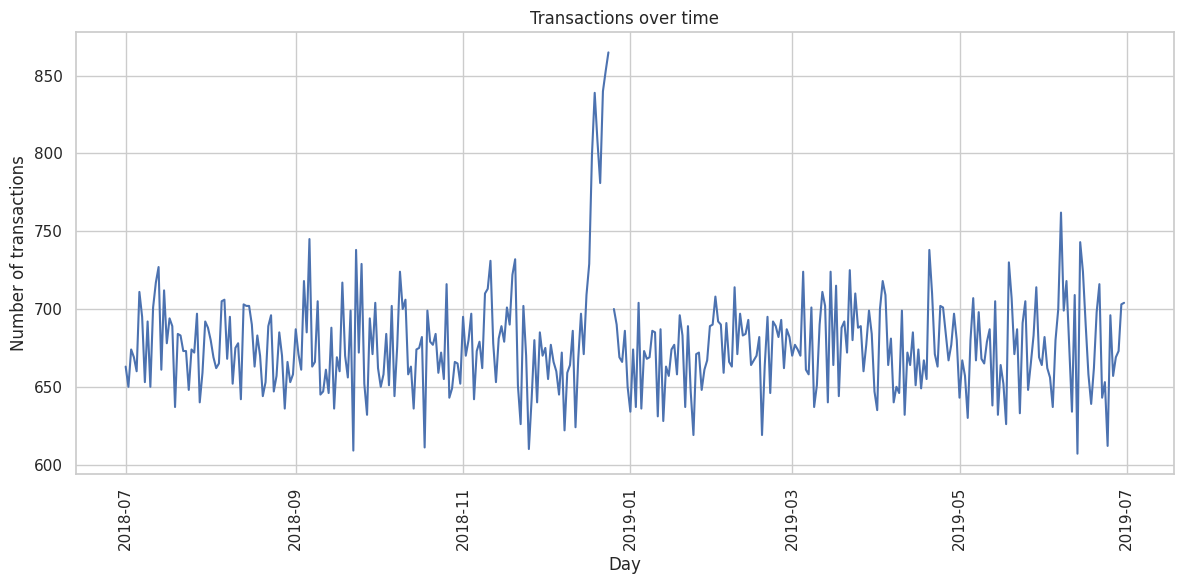

In [39]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6)) #width, height in inches
plt.plot(trans_counts_date_full.index, trans_counts_date_full.values) # Plotting the number of transactions over time
plt.xlabel("Day")
plt.ylabel("Number of transactions")
plt.title("Transactions over time", loc='center')
plt.xticks(rotation=90) # Rotate x-axis labels
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

A significant spike is observed between November 2018 and January 2019. The subsequent analysis focuses on examining the duration and characteristics of this period.

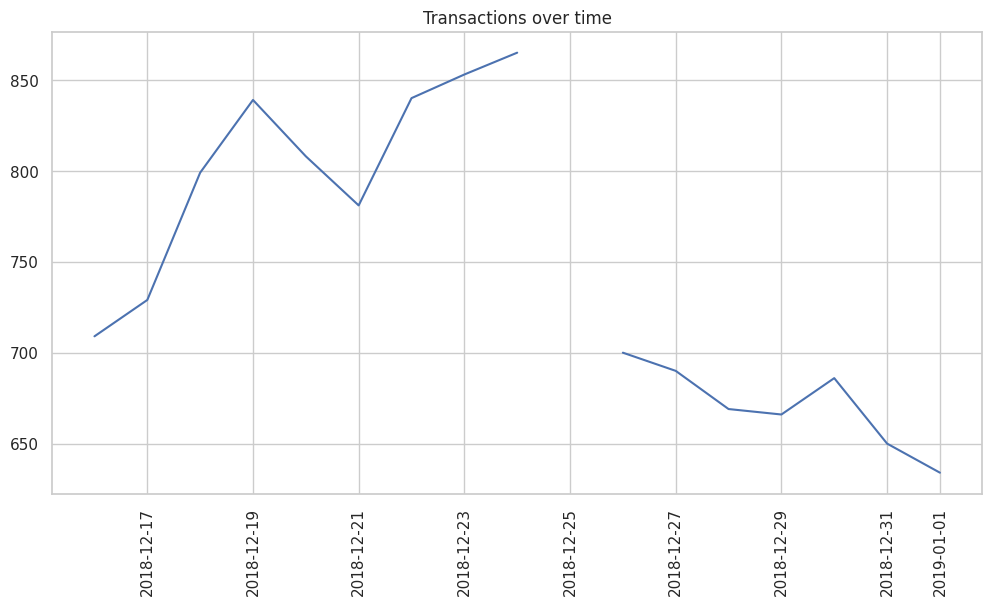

In [40]:
#zoom in on the period from 2018-12-01 to 2019-01-01
trans_counts_date_full_zoomed = trans_counts_date_full[(trans_counts_date_full.index >= '2018-12-16') & (trans_counts_date_full.index <= '2019-01-01')]
plt.figure(figsize=(12,6))
plt.plot(trans_counts_date_full_zoomed.index, trans_counts_date_full_zoomed.values)

plt.xticks(rotation=90)
plt.title("Transactions over time")
plt.show()

In [41]:
top10 = trans_counts_date_full.sort_values(
    by='Transaction_count',
    ascending=False
).head(10)

<Figure size 1800x800 with 0 Axes>

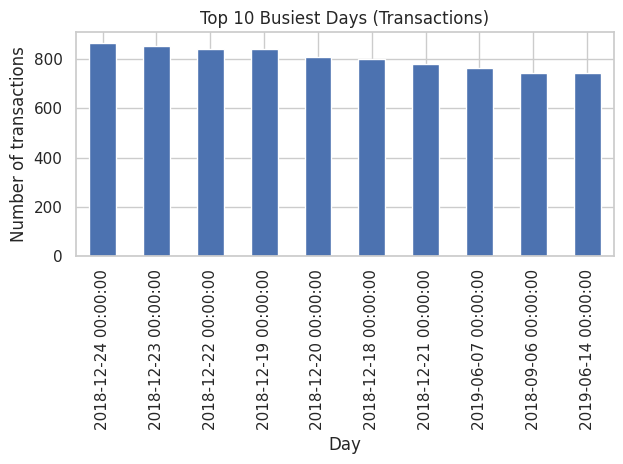

In [42]:
plt.figure(figsize=(18,8))

top10.plot(kind='bar')

plt.xlabel("Day")
plt.ylabel("Number of transactions")
plt.title("Top 10 Busiest Days (Transactions)")
plt.xticks(rotation=90)

plt.legend().remove() 

plt.tight_layout()
plt.show()

The top eight transaction peaks occur in the period leading up to Christmas, suggesting increased purchasing activity driven by seasonal demand. Further analysis is conducted to examine other peak periods.

In [43]:
trans_counts_extract = trans_counts_date_full[(trans_counts_date_full.index <= '2018-12-06') | (trans_counts_date_full.index >= '2018-12-26')]

In [44]:
top10_beyond_christmas=trans_counts_extract.sort_values(
    by='Transaction_count',
    ascending=False).head(10)

print(top10_beyond_christmas)

            Transaction_count
2019-06-07              762.0
2018-09-06              745.0
2019-06-14              743.0
2019-04-20              738.0
2018-09-23              738.0
2018-11-20              732.0
2018-11-11              731.0
2019-05-19              730.0
2018-09-25              729.0
2018-07-13              727.0


In [45]:
top10_by_sorted = top10_beyond_christmas.sort_values(by='Transaction_count')

<Figure size 1200x500 with 0 Axes>

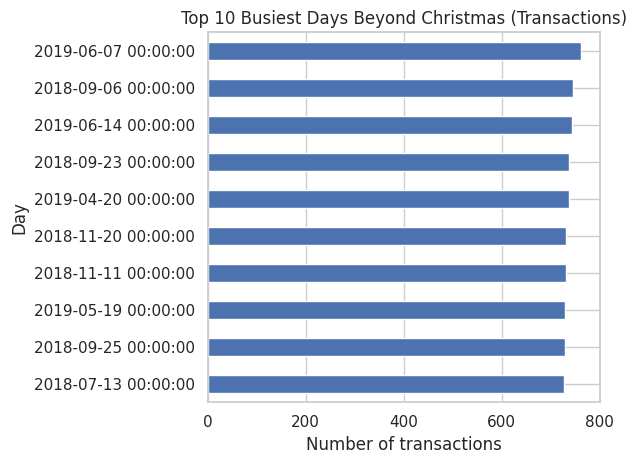

In [46]:
plt.figure(figsize=(12,5))

top10_by_sorted.plot(kind='barh', legend=False)

plt.xlabel("Number of transactions")
plt.ylabel("Day")
plt.title("Top 10 Busiest Days Beyond Christmas (Transactions)")

plt.tight_layout()
plt.show()

Outside the Christmas period, the top 10 transaction peaks show relatively stable patterns with no significant outliers. This suggests that these peaks are isolated events rather than part of a strong seasonal trend.

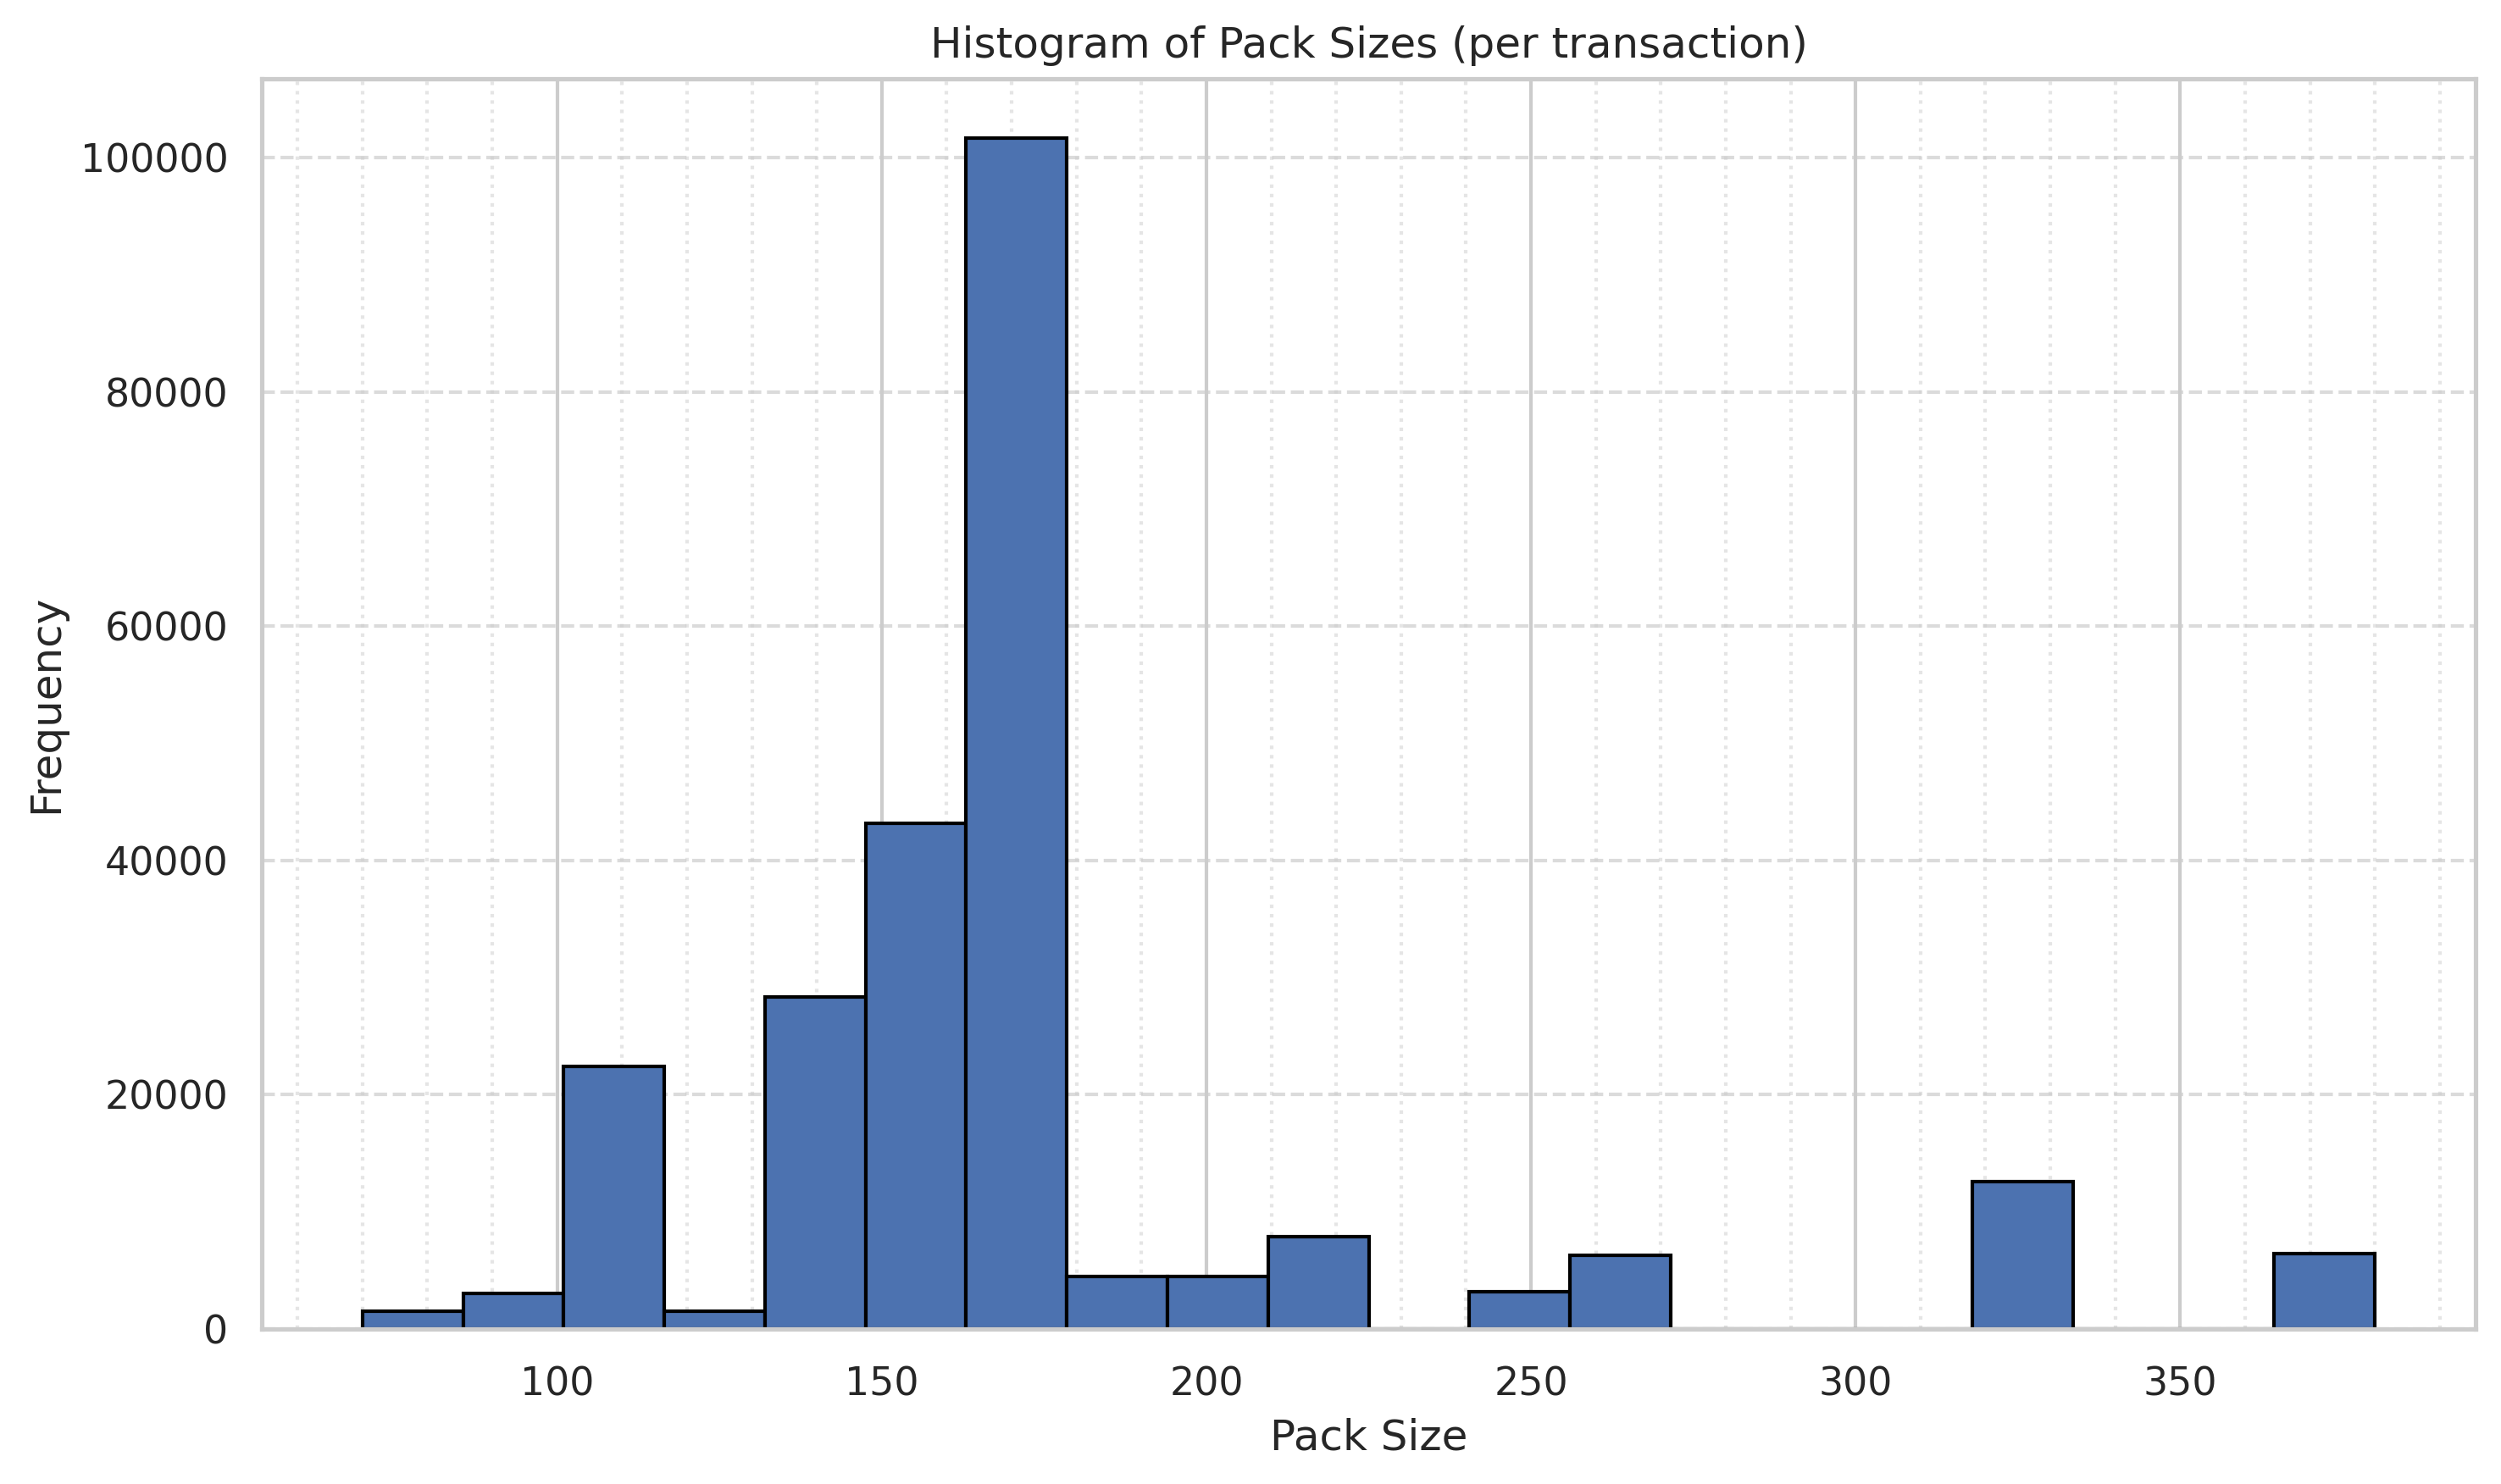

In [47]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10,6),dpi=300)
plt.hist(merged_data['PACK_SIZE'].dropna(), bins=20, edgecolor='black')

plt.xlabel('Pack Size')
plt.ylabel('Frequency')
plt.title('Histogram of Pack Sizes (per transaction)')

# subdivide x-axis ticks
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))   # main ticks every 50
ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))   # smaller subdivisions every 10

# force minor ticks to show
ax.minorticks_on()

# make them visible
ax.tick_params(axis='x', which='major', length=7)
ax.tick_params(axis='x', which='minor', length=4)

# add minor grid so you can actually see subdivisions
ax.grid(which='minor', axis='x', linestyle=':', alpha=0.5)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Although packet sizes range from 70g to 380g, purchases concentrate in the 140g–180g range. This reflects a preference for mid-sized products.

Customer purchasing behavior is analyzed across life stages and premium customer segments to identify differences in purchasing patterns.

In [48]:
# Total sales by LIFESTAGE and PREMIUM_CUSTOMER
tot_grouped = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg({
    'TOT_SALES': 'sum',
    'TXN_ID': 'count'
}).reset_index()

In [49]:
premium_colors = {
    'Premium': '#355C7D',     # deep steel blue
    'Mainstream': '#6C7A89',  # slate gray
    'Budget': '#D9A441'       # muted gold
}

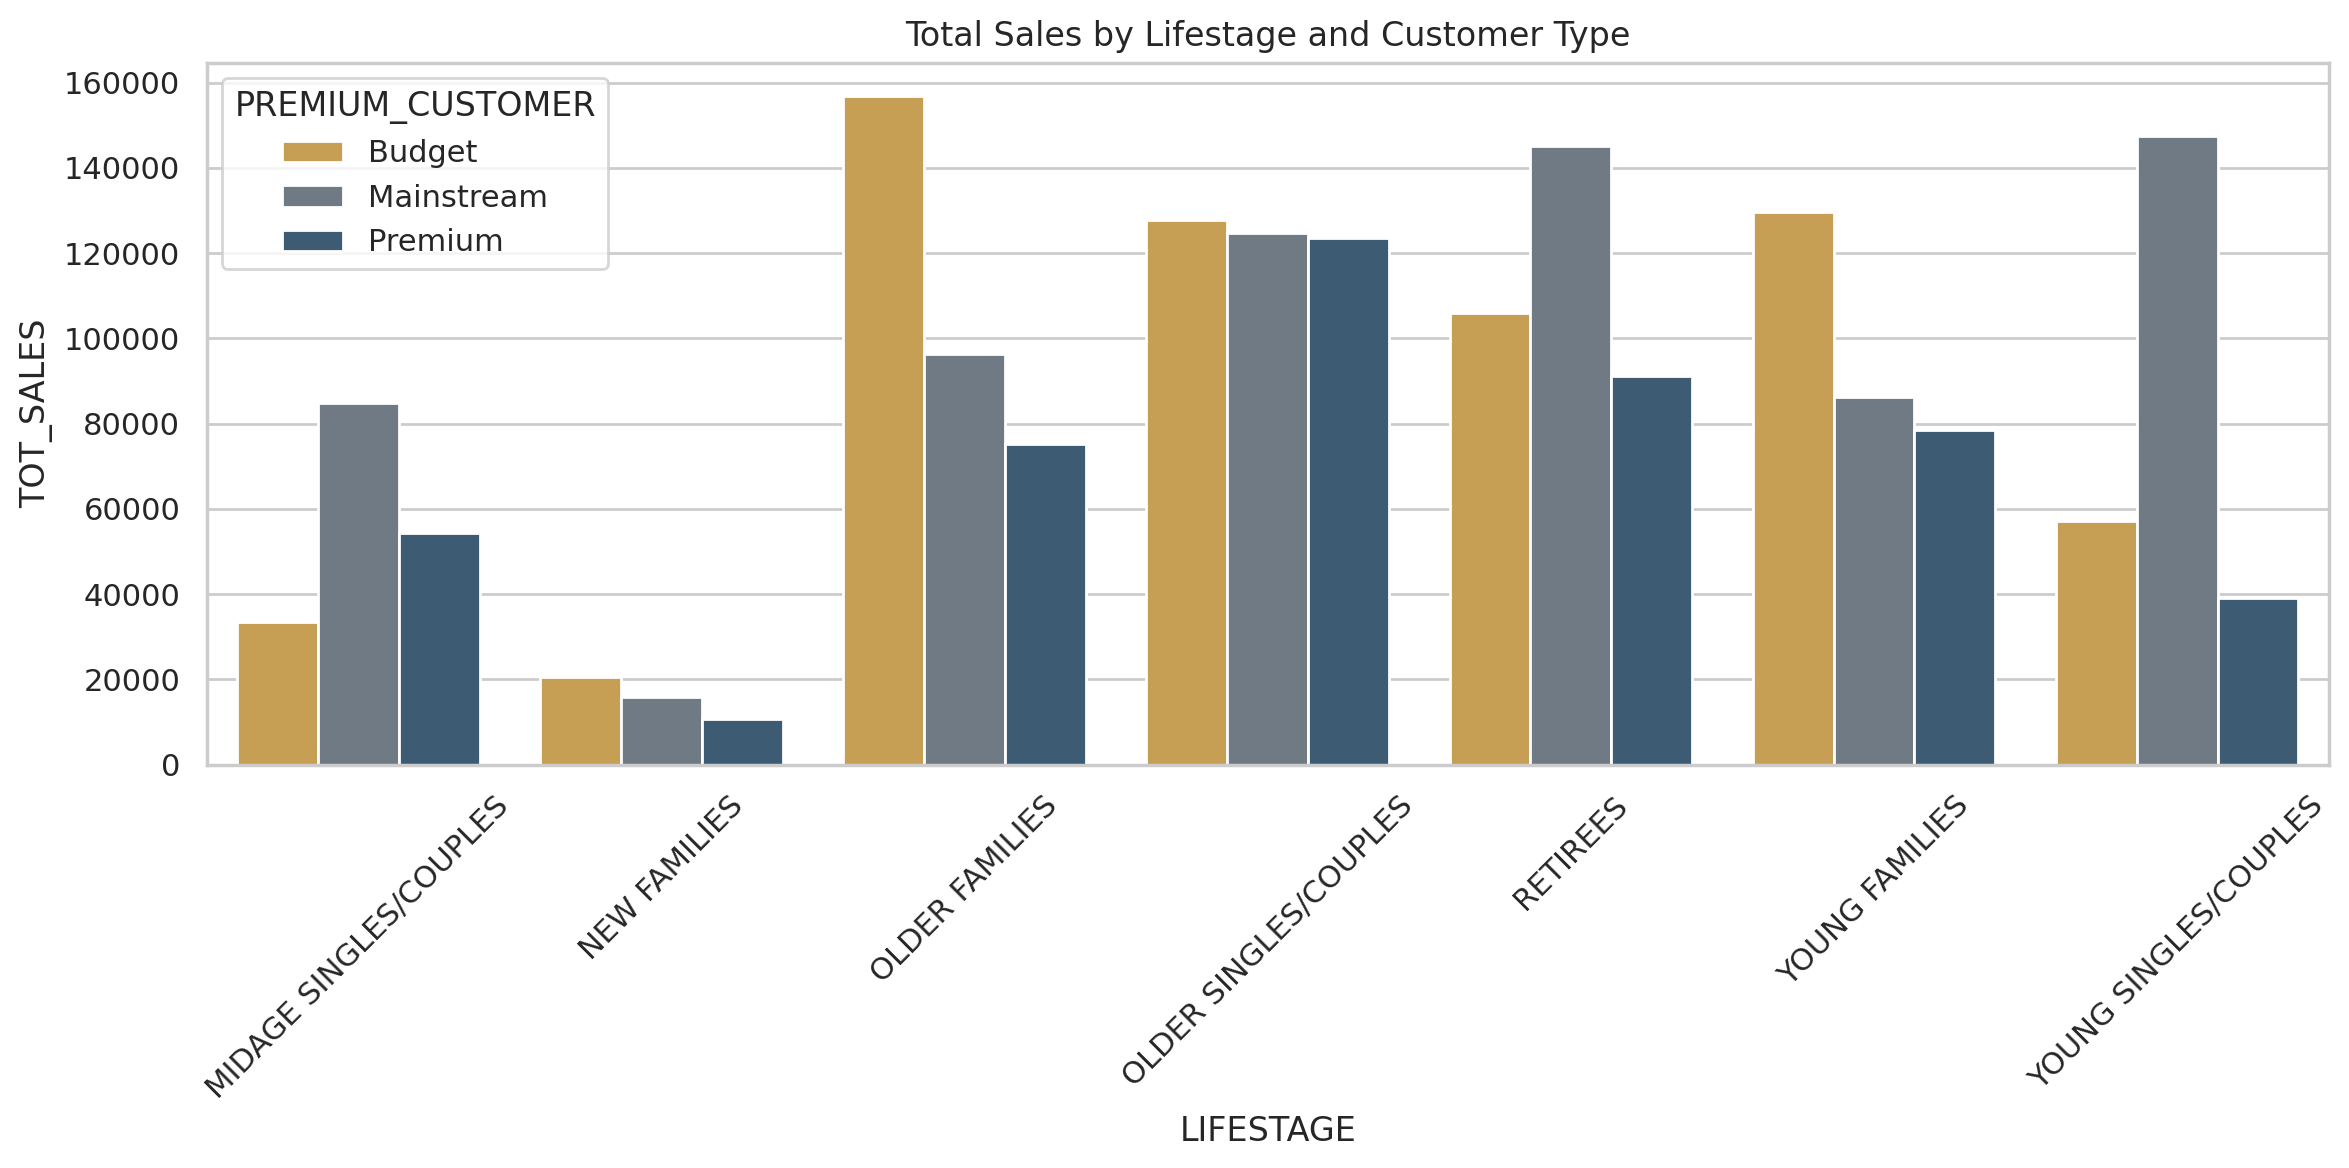

In [50]:
plt.figure(figsize=(12,6), dpi=200)
sns.barplot(
    data=tot_grouped,
    x='LIFESTAGE',
    y='TOT_SALES',
    hue='PREMIUM_CUSTOMER',
    palette = premium_colors 

)

plt.xticks(rotation=45)
plt.title("Total Sales by Lifestage and Customer Type")
plt.tight_layout()
plt.show()

Older singles/couples show similar sales across customer types. So, focus can be shifted to higher-variation segments.
Within the young singles/couples segment, mainstream customers account for the majority of sales, while budget and premium customers underperform. This suggests potential to increase overall spend through targeted incentives aimed at these lower-contributing subgroups.


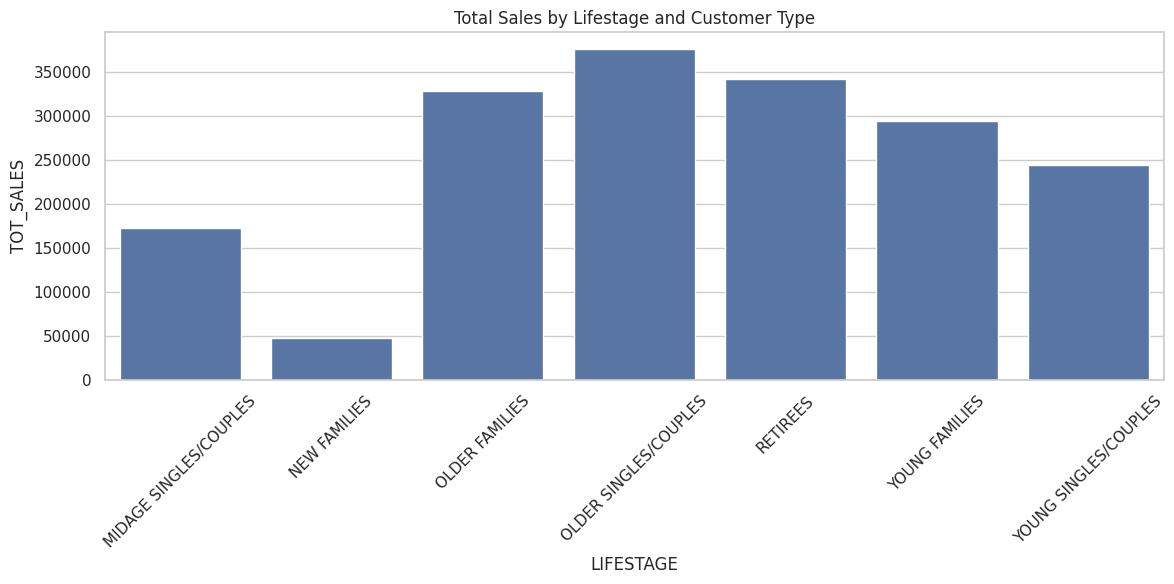

In [51]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=tot_grouped,
    x='LIFESTAGE',
    y='TOT_SALES',
    estimator=np.sum,
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Total Sales by Lifestage and Customer Type")
plt.tight_layout()
plt.show()

In terms of total sales, budget customers among older families contribute the most, followed by mainstream customers among young singles/couples, and then mainstream customers among retirees. Overall, older singles/couples contribute about 20.8% of the total sales.

In [52]:
cust_grouped = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()

In [53]:
print(cust_grouped)

                 LIFESTAGE PREMIUM_CUSTOMER  LYLTY_CARD_NBR
0   MIDAGE SINGLES/COUPLES           Budget            1474
1   MIDAGE SINGLES/COUPLES       Mainstream            3298
2   MIDAGE SINGLES/COUPLES          Premium            2369
3             NEW FAMILIES           Budget            1087
4             NEW FAMILIES       Mainstream             830
5             NEW FAMILIES          Premium             575
6           OLDER FAMILIES           Budget            4611
7           OLDER FAMILIES       Mainstream            2788
8           OLDER FAMILIES          Premium            2231
9    OLDER SINGLES/COUPLES           Budget            4849
10   OLDER SINGLES/COUPLES       Mainstream            4858
11   OLDER SINGLES/COUPLES          Premium            4682
12                RETIREES           Budget            4385
13                RETIREES       Mainstream            6358
14                RETIREES          Premium            3812
15          YOUNG FAMILIES           Bud

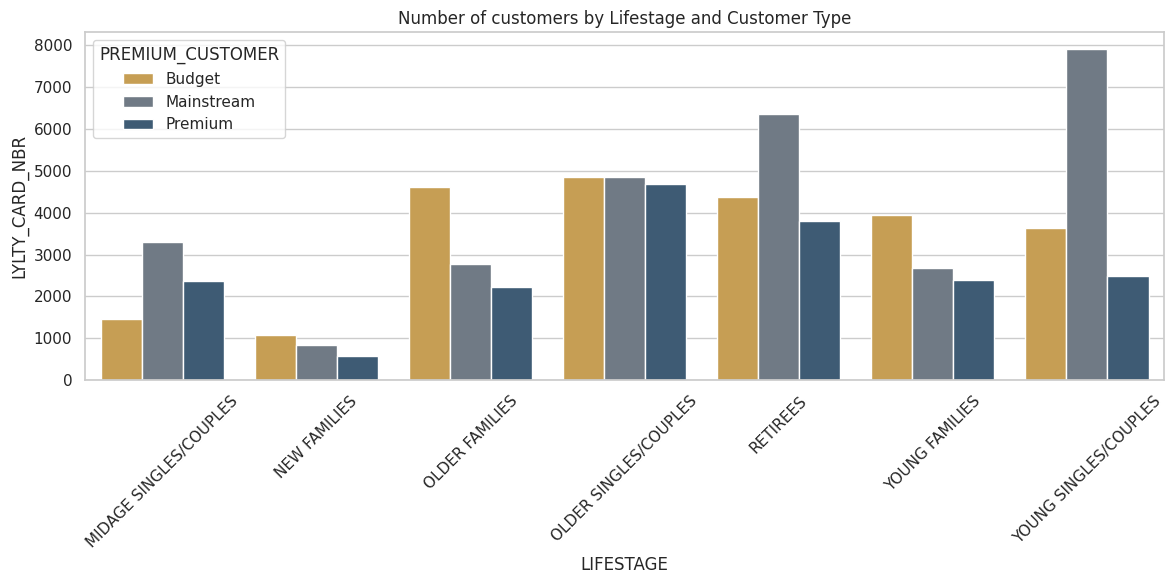

In [54]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=cust_grouped,
    x='LIFESTAGE',
    y='LYLTY_CARD_NBR',
    hue='PREMIUM_CUSTOMER',
    palette = premium_colors 
)
plt.xticks(rotation=45)
plt.title("Number of customers by Lifestage and Customer Type")
plt.tight_layout()
plt.show()

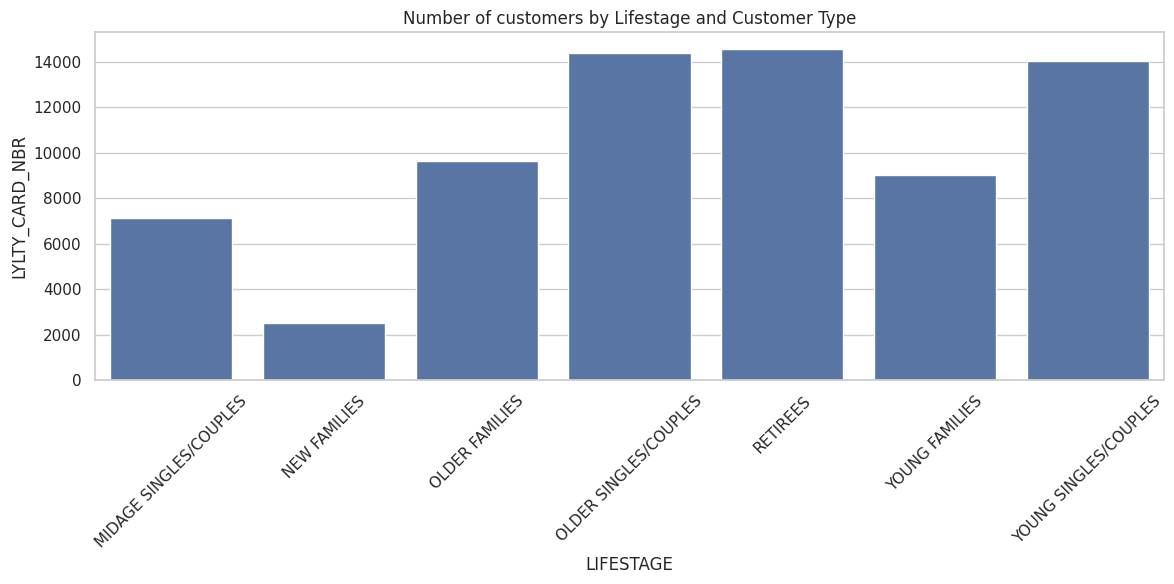

In [55]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=cust_grouped,
    x='LIFESTAGE',
    y='LYLTY_CARD_NBR',
    estimator=np.sum,
     errorbar=None
)
plt.xticks(rotation=45)
plt.title("Number of customers by Lifestage and Customer Type")
plt.tight_layout()
plt.show()

In [56]:
donut_sales = merged_data.groupby('LIFESTAGE')['TOT_SALES'].sum()
donut_sales = donut_sales.sort_values(ascending=False)

In [57]:
donut_num = (
    merged_data
    .groupby('LIFESTAGE')['LYLTY_CARD_NBR']
    .nunique()
    .reset_index()
)

donut_num = donut_num.sort_values(
    by='LYLTY_CARD_NBR',
    ascending=False
)

In [58]:
color_map = {
    "RETIREES": "#4C72B0",
    "OLDER SINGLES/COUPLES": "#55A868",
    "YOUNG SINGLES/COUPLES": "#C44E52",
    "OLDER FAMILIES": "#8172B2",
    "YOUNG FAMILIES": "#CCB974",
    "MIDAGE SINGLES/COUPLES": "#64B5CD",
    "NEW FAMILIES": "#8C8C8C"
}


Mainstream customers among young singles/couples represent the highest shopping activity, followed by mainstream retirees, and then budget and mainstream customers among older singles/couples.

Looking at overall visit frequency, retirees visit the store most often, followed by older singles/couples, and then young singles/couples

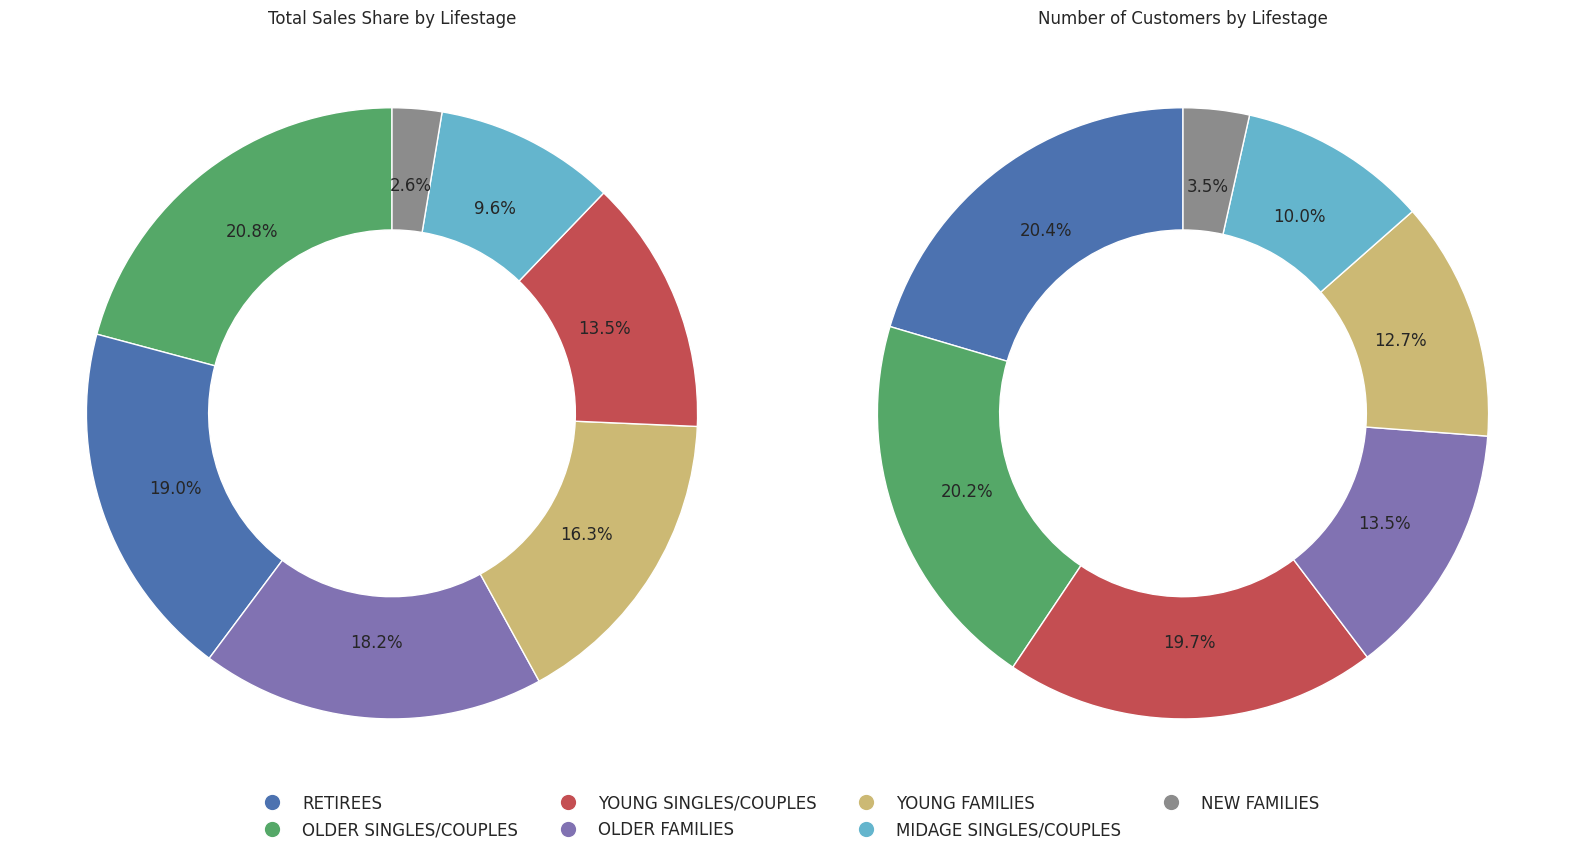

In [59]:

# --- Create color list for each dataset ---
colors_num = donut_num['LIFESTAGE'].map(color_map)
colors_sales = donut_sales.index.map(color_map)

# --- Create figure with 1 row, 2 columns ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ---------------- LEFT PIE (Sales) ----------------
axes[0].pie(
    donut_sales.values,
    labels=None,                 # no labels on donut
    colors=colors_sales,
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=90,
    wedgeprops=dict(width=0.4)
)
axes[0].set_title("Total Sales Share by Lifestage")

# ---------------- RIGHT PIE (Customer Count) ----------------
axes[1].pie(
    donut_num['LYLTY_CARD_NBR'],
    labels=None,                 # no labels on donut
    colors=colors_num,
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=90,
    wedgeprops=dict(width=0.4)
)
axes[1].set_title("Number of Customers by Lifestage")

# ---------------- BOTTOM LEGEND ----------------
# Use unique categories in the order of color_map
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=color_map[k], markersize=12)
    for k in color_map.keys()
]

fig.legend(
    handles,
    color_map.keys(),
    loc='lower center',
    ncol=4,                      # spreads legend horizontally
    frameon=False,
    fontsize=12,
    bbox_to_anchor=(0.5, -0.05) # pushes legend below the charts
)

plt.tight_layout()
plt.show()


In [60]:
avg_units = (
    merged_data
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .agg(
        total_units=('PROD_QTY', 'sum'),
        num_customers=('LYLTY_CARD_NBR', 'nunique')
    )
)
print(avg_units)

                                         total_units  num_customers
LIFESTAGE              PREMIUM_CUSTOMER                            
MIDAGE SINGLES/COUPLES Budget                   8883           1474
                       Mainstream              21213           3298
                       Premium                 14400           2369
NEW FAMILIES           Budget                   5241           1087
                       Mainstream               4060            830
                       Premium                  2769            575
OLDER FAMILIES         Budget                  41853           4611
                       Mainstream              25804           2788
                       Premium                 20239           2231
OLDER SINGLES/COUPLES  Budget                  32883           4849
                       Mainstream              32607           4858
                       Premium                 31695           4682
RETIREES               Budget                  2

In [61]:
avg_units['avg_units_per_customer'] = (
    avg_units['total_units'] / avg_units['num_customers']
)

avg_units = avg_units.reset_index()
print(avg_units)

                 LIFESTAGE PREMIUM_CUSTOMER  total_units  num_customers  \
0   MIDAGE SINGLES/COUPLES           Budget         8883           1474   
1   MIDAGE SINGLES/COUPLES       Mainstream        21213           3298   
2   MIDAGE SINGLES/COUPLES          Premium        14400           2369   
3             NEW FAMILIES           Budget         5241           1087   
4             NEW FAMILIES       Mainstream         4060            830   
5             NEW FAMILIES          Premium         2769            575   
6           OLDER FAMILIES           Budget        41853           4611   
7           OLDER FAMILIES       Mainstream        25804           2788   
8           OLDER FAMILIES          Premium        20239           2231   
9    OLDER SINGLES/COUPLES           Budget        32883           4849   
10   OLDER SINGLES/COUPLES       Mainstream        32607           4858   
11   OLDER SINGLES/COUPLES          Premium        31695           4682   
12                RETIREE

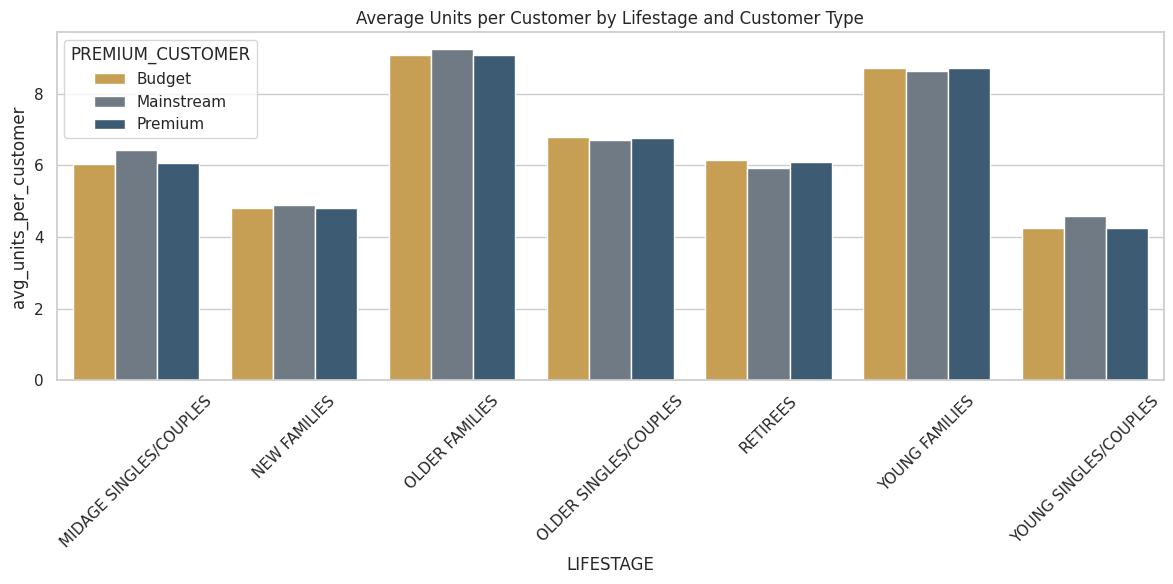

In [62]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=avg_units,
    x='LIFESTAGE',
    y='avg_units_per_customer',
    hue='PREMIUM_CUSTOMER',
    palette = premium_colors 
)

plt.xticks(rotation=45)
plt.title("Average Units per Customer by Lifestage and Customer Type")
plt.tight_layout()
plt.show()

Although older families have relatively lower shopping activity, the three customer segments within this group record the highest average units per customer, suggesting they purchase more per visit. This is also reflected in their contribution to total sales. Mainstream customers among older families lead this category.

A similar pattern is observed among young families, where lower store visit frequency is offset by higher average units per customer across the three segments. In contrast, young singles/couples exhibit the lowest average units per customer despite being among the more frequent store visitors.

In [63]:
avg_price = (
    merged_data
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .agg(
        total_sales=('TOT_SALES', 'sum'),
        total_units=('PROD_QTY', 'sum')
    )
)

In [64]:
avg_price['avg_price_per_unit'] = (
    avg_price['total_sales'] / avg_price['total_units']
)

avg_price = avg_price.reset_index()
print(avg_price)

                 LIFESTAGE PREMIUM_CUSTOMER  total_sales  total_units  \
0   MIDAGE SINGLES/COUPLES           Budget     33345.70         8883   
1   MIDAGE SINGLES/COUPLES       Mainstream     84734.25        21213   
2   MIDAGE SINGLES/COUPLES          Premium     54443.85        14400   
3             NEW FAMILIES           Budget     20607.45         5241   
4             NEW FAMILIES       Mainstream     15979.70         4060   
5             NEW FAMILIES          Premium     10760.80         2769   
6           OLDER FAMILIES           Budget    156863.75        41853   
7           OLDER FAMILIES       Mainstream     96413.55        25804   
8           OLDER FAMILIES          Premium     75242.60        20239   
9    OLDER SINGLES/COUPLES           Budget    127833.60        32883   
10   OLDER SINGLES/COUPLES       Mainstream    124648.50        32607   
11   OLDER SINGLES/COUPLES          Premium    123537.55        31695   
12                RETIREES           Budget    1059

In [65]:
avg_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LIFESTAGE           21 non-null     object 
 1   PREMIUM_CUSTOMER    21 non-null     object 
 2   total_sales         21 non-null     float64
 3   total_units         21 non-null     int64  
 4   avg_price_per_unit  21 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 972.0+ bytes


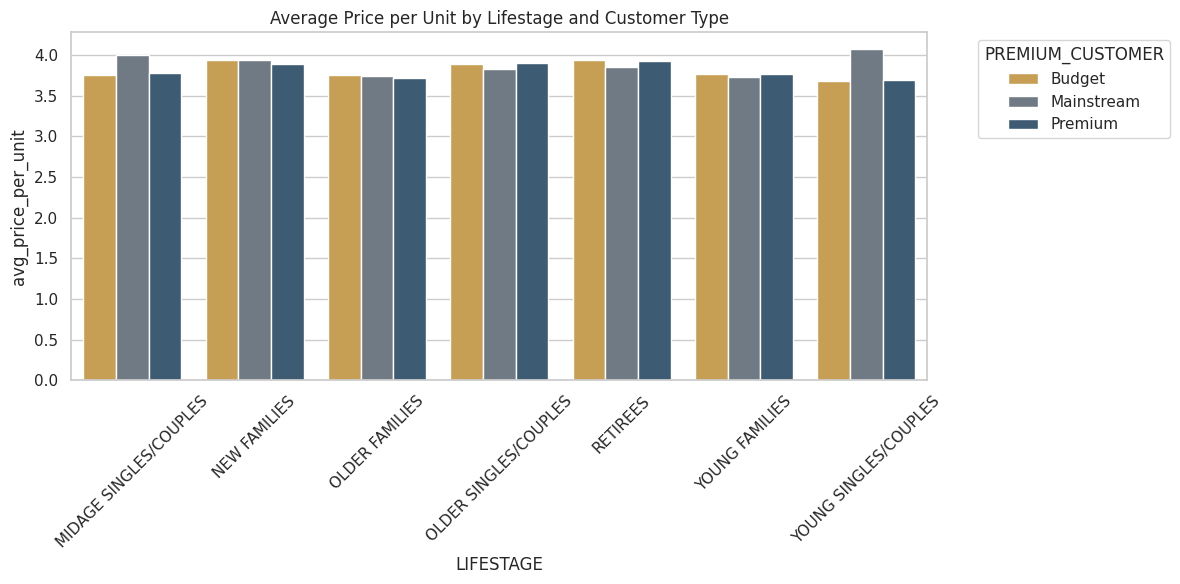

In [66]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=avg_price,
    x='LIFESTAGE',
    y='avg_price_per_unit',
    hue='PREMIUM_CUSTOMER',
    palette = premium_colors 
)

plt.xticks(rotation=45)
plt.title("Average Price per Unit by Lifestage and Customer Type")

# move legend outside
plt.legend(title='PREMIUM_CUSTOMER', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Mainstream customers among young singles/couples tend to select higher-priced items per unit, on average, and are frequent store visitors, as shown in previous analysis. This is followed by mainstream customers among mid-aged singles/couples. This is notable given that mid-aged singles/couples have the second-lowest store-visit frequency.

The average price per unit is similar across the various categories. Therefore, t-tests are performed to determine whether the observed differences are statistically significant.

In [67]:
budget = merged_data[merged_data['PREMIUM_CUSTOMER'] == 'Budget']['TOT_SALES'] / \
         merged_data[merged_data['PREMIUM_CUSTOMER'] == 'Budget']['PROD_QTY']

premium = merged_data[merged_data['PREMIUM_CUSTOMER'] == 'Premium']['TOT_SALES'] / \
          merged_data[merged_data['PREMIUM_CUSTOMER'] == 'Premium']['PROD_QTY']
mainstream = merged_data[merged_data['PREMIUM_CUSTOMER'] == 'Mainstream']['TOT_SALES'] / \
              merged_data[merged_data['PREMIUM_CUSTOMER'] == 'Mainstream']['PROD_QTY']

t_stat_bp, p_value_bp = ttest_ind(budget, premium, equal_var=False)
t_stat_bm, p_value_bm = ttest_ind(budget, mainstream, equal_var=False)
t_stat_pm, p_value_pm = ttest_ind(premium, mainstream, equal_var=False)

print(p_value_bp)
print(p_value_bm)
print(p_value_pm)

0.0441329023844867
5.380219545070533e-46
2.0788364041187993e-28


In [68]:
budget_young = merged_data.loc[(merged_data['PREMIUM_CUSTOMER'] == 'Budget') & (merged_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES'),'TOT_SALES'] / \
                 merged_data.loc[(merged_data['PREMIUM_CUSTOMER'] == 'Budget') & (merged_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES'),'PROD_QTY']

budget_middle = merged_data.loc[(merged_data['PREMIUM_CUSTOMER'] == 'Budget') & (merged_data['LIFESTAGE'] == 'MIDAGE SINGLES/COUPLES'),'TOT_SALES'] / \
                 merged_data.loc[(merged_data['PREMIUM_CUSTOMER'] == 'Budget') & (merged_data['LIFESTAGE'] == 'MIDAGE SINGLES/COUPLES'),'PROD_QTY']

t_stat_bd_yg, p_value_bd_yg = ttest_ind(budget_young, budget_middle, equal_var=False)
print(p_value_bd_yg)

1.4196195274595408e-05


The p-values across all categories are below the 0.05 significance level, indicating that the observed differences are statistically significant.

The brand and packet size preferences of mainstream young singles/couples are analyzed to understand their purchasing behavior.

In [69]:
merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'BRAND_NAME']).size()

LIFESTAGE               PREMIUM_CUSTOMER  BRAND_NAME
MIDAGE SINGLES/COUPLES  Budget            BURGER         43
                                          CCS           112
                                          CHEETOS        61
                                          CHEEZELS       74
                                          COBS          180
                                                       ... 
YOUNG SINGLES/COUPLES   Premium           THINS         330
                                          TOSTITOS      203
                                          TWISTIES      195
                                          TYRRELLS      132
                                          WOOLWORTHS    393
Length: 420, dtype: int64

In [70]:
overall_brand_seg= (
    merged_data
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'BRAND_NAME'])['PROD_QTY']
    .sum()
    .reset_index(name='TOT_QTY')
)
print(overall_brand_seg)

                  LIFESTAGE PREMIUM_CUSTOMER  BRAND_NAME  TOT_QTY
0    MIDAGE SINGLES/COUPLES           Budget      BURGER       84
1    MIDAGE SINGLES/COUPLES           Budget         CCS      205
2    MIDAGE SINGLES/COUPLES           Budget     CHEETOS      112
3    MIDAGE SINGLES/COUPLES           Budget    CHEEZELS      139
4    MIDAGE SINGLES/COUPLES           Budget        COBS      345
..                      ...              ...         ...      ...
415   YOUNG SINGLES/COUPLES          Premium       THINS      614
416   YOUNG SINGLES/COUPLES          Premium    TOSTITOS      386
417   YOUNG SINGLES/COUPLES          Premium    TWISTIES      359
418   YOUNG SINGLES/COUPLES          Premium    TYRRELLS      236
419   YOUNG SINGLES/COUPLES          Premium  WOOLWORTHS      688

[420 rows x 4 columns]


In [71]:
overall_brand_share = (
    overall_brand_seg
    .groupby('BRAND_NAME')['TOT_QTY']
    .sum()
    .reset_index()
)
print(overall_brand_share)

    BRAND_NAME  TOT_QTY
0       BURGER     2970
1          CCS     8609
2      CHEETOS     5530
3     CHEEZELS     8747
4         COBS    18571
5      DORITOS    48331
6       FRENCH     2643
7   GRAINWAVES    14726
8    INFUZIONS    27119
9       KETTLE    79051
10         NCC    14106
11    PRINGLES    48019
12         RRD    30891
13      SMITHS    57582
14    SUNBITES     5692
15       THINS    26929
16    TOSTITOS    18134
17    TWISTIES    18118
18    TYRRELLS    12298
19  WOOLWORTHS    22333


In [72]:
top10_brands = (
    overall_brand_share
    .sort_values(by='TOT_QTY', ascending=False)
    .head(10)
    ['BRAND_NAME']
)

print(top10_brands)

9         KETTLE
13        SMITHS
5        DORITOS
11      PRINGLES
12           RRD
8      INFUZIONS
15         THINS
19    WOOLWORTHS
4           COBS
16      TOSTITOS
Name: BRAND_NAME, dtype: object


In [73]:
overall_brand_top10 = overall_brand_seg[overall_brand_seg['BRAND_NAME'].isin(top10_brands)]
print(overall_brand_top10)

                  LIFESTAGE PREMIUM_CUSTOMER  BRAND_NAME  TOT_QTY
4    MIDAGE SINGLES/COUPLES           Budget        COBS      345
5    MIDAGE SINGLES/COUPLES           Budget     DORITOS      922
8    MIDAGE SINGLES/COUPLES           Budget   INFUZIONS      534
9    MIDAGE SINGLES/COUPLES           Budget      KETTLE     1365
11   MIDAGE SINGLES/COUPLES           Budget    PRINGLES      854
..                      ...              ...         ...      ...
412   YOUNG SINGLES/COUPLES          Premium         RRD      775
413   YOUNG SINGLES/COUPLES          Premium      SMITHS     1405
415   YOUNG SINGLES/COUPLES          Premium       THINS      614
416   YOUNG SINGLES/COUPLES          Premium    TOSTITOS      386
419   YOUNG SINGLES/COUPLES          Premium  WOOLWORTHS      688

[210 rows x 4 columns]


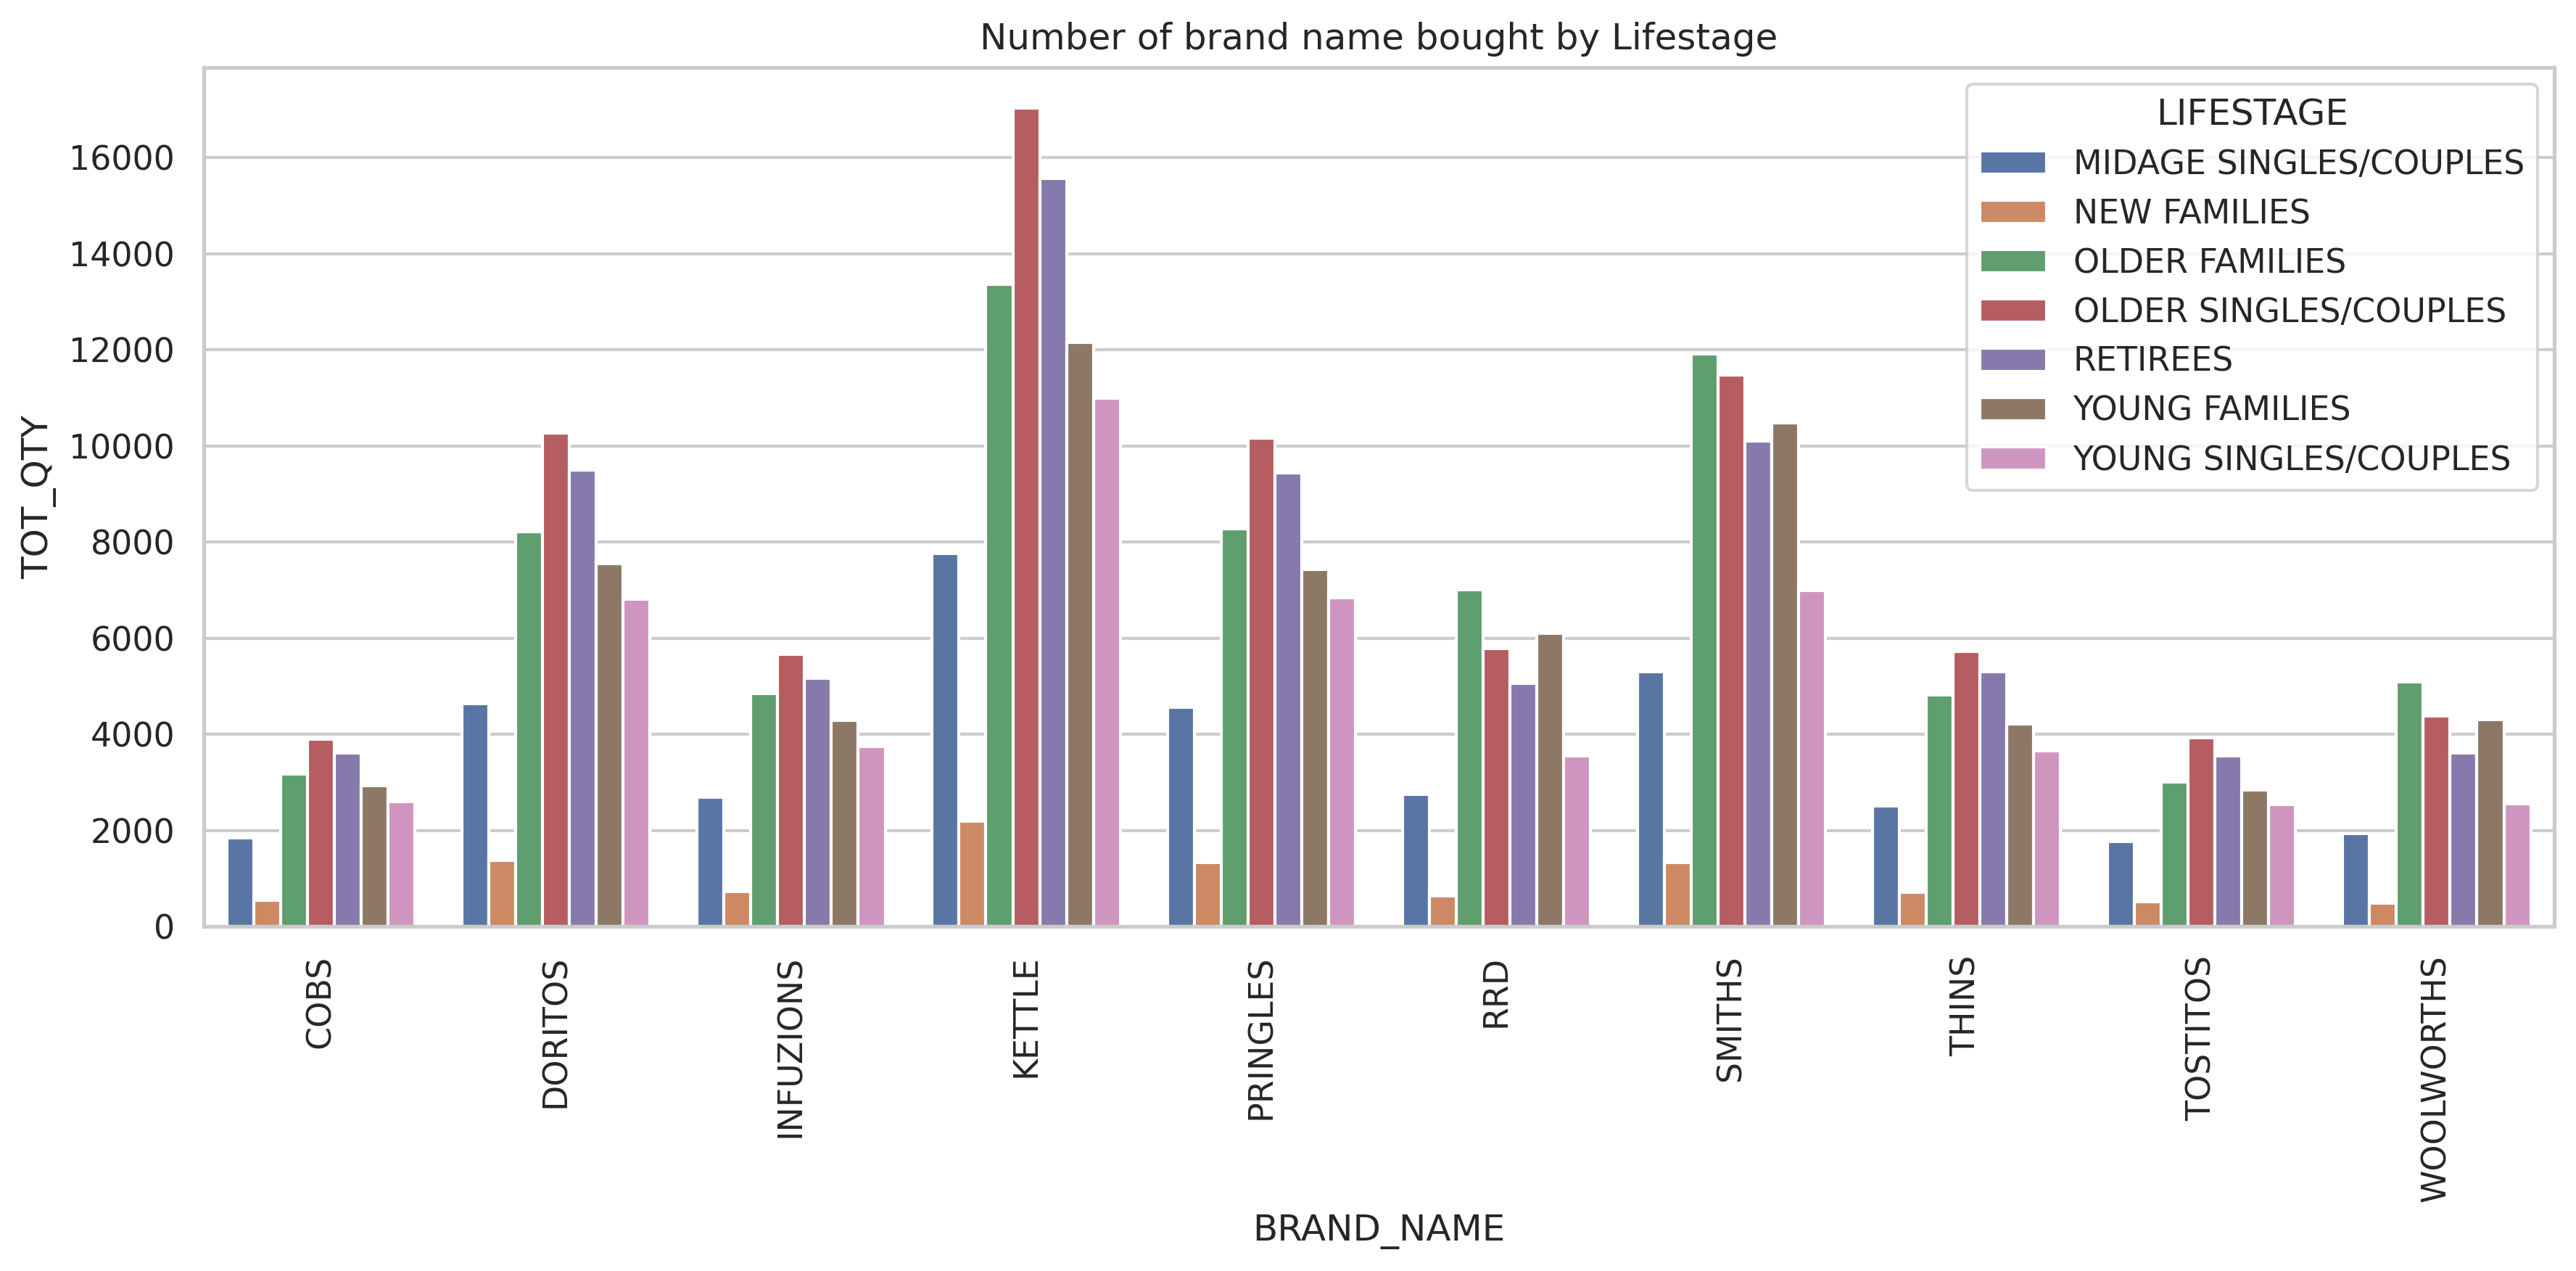

In [74]:
plt.figure(figsize=(12,6), dpi=300)


ax = sns.barplot(
    data= overall_brand_top10,
    x='BRAND_NAME',
    y='TOT_QTY',
    hue='LIFESTAGE',
    estimator=np.sum,
    errorbar=None
)

plt.xticks(rotation=90)
plt.title("Number of brand name bought by Lifestage")

# move legend outside
#plt.legend(title='LIFESTAGE', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

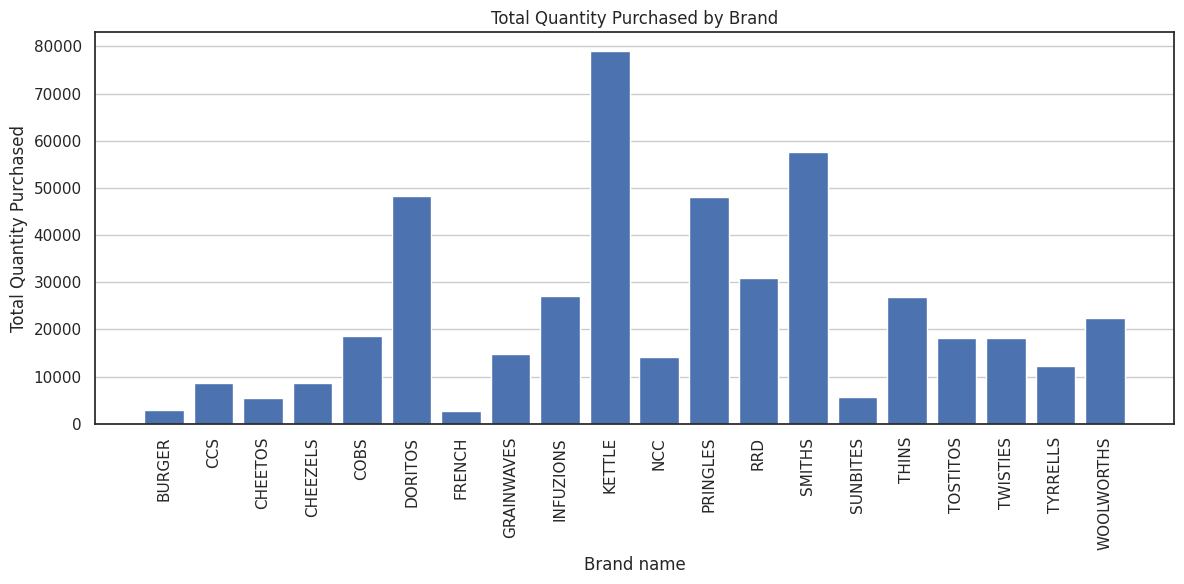

In [75]:
sns.set_style("white")

plt.figure(figsize=(12,6))

plt.bar(
    overall_brand_share['BRAND_NAME'],
    overall_brand_share['TOT_QTY']
)

plt.xticks(rotation=90)
plt.xlabel("Brand name")
plt.ylabel("Total Quantity Purchased")
plt.title("Total Quantity Purchased by Brand")

# remove vertical tick lines completely
plt.tick_params(axis='x', which='both', bottom=False, top=False)

# keep only horizontal gridlines
plt.grid(axis='y')

# ensure no vertical gridlines
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

In [76]:
segment_yg_main = merged_data[
    (merged_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') &
    (merged_data['PREMIUM_CUSTOMER'] == 'Mainstream')
]

In [77]:
print(segment_yg_main)

             DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
221345 2018-08-16          1            1020      26        19   
221346 2018-08-17          1            1163     188        46   
221347 2018-08-14          1            1291     333        27   
221348 2019-05-15          3            3031    1227        14   
221349 2019-05-18          3            3118    1574        62   
...           ...        ...             ...     ...       ...   
240884 2018-12-01        272          272377  270186        75   
240885 2018-07-27        272          272389  270200       114   
240886 2018-11-10        272          272389  270201        26   
240887 2019-04-01        272          272389  270202        62   
240888 2018-12-07        272          272391  270205        63   

                                     PROD_NAME  PROD_QTY  TOT_SALES  \
221345     Smiths Crinkle Cut  Snag&Sauce 150g         1        2.6   
221346                    Kettle Original 175g         1        5

In [78]:
brand_share_yg=overall_brand_seg[
    (overall_brand_seg['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') &
    (overall_brand_seg['PREMIUM_CUSTOMER'] == 'Mainstream')]
print(brand_share_yg)

                 LIFESTAGE PREMIUM_CUSTOMER  BRAND_NAME  TOT_QTY
380  YOUNG SINGLES/COUPLES       Mainstream      BURGER      106
381  YOUNG SINGLES/COUPLES       Mainstream         CCS      405
382  YOUNG SINGLES/COUPLES       Mainstream     CHEETOS      291
383  YOUNG SINGLES/COUPLES       Mainstream    CHEEZELS      651
384  YOUNG SINGLES/COUPLES       Mainstream        COBS     1617
385  YOUNG SINGLES/COUPLES       Mainstream     DORITOS     4447
386  YOUNG SINGLES/COUPLES       Mainstream      FRENCH      143
387  YOUNG SINGLES/COUPLES       Mainstream  GRAINWAVES     1185
388  YOUNG SINGLES/COUPLES       Mainstream   INFUZIONS     2343
389  YOUNG SINGLES/COUPLES       Mainstream      KETTLE     7172
390  YOUNG SINGLES/COUPLES       Mainstream         NCC      710
391  YOUNG SINGLES/COUPLES       Mainstream    PRINGLES     4326
392  YOUNG SINGLES/COUPLES       Mainstream         RRD     1587
393  YOUNG SINGLES/COUPLES       Mainstream      SMITHS     3491
394  YOUNG SINGLES/COUPLE

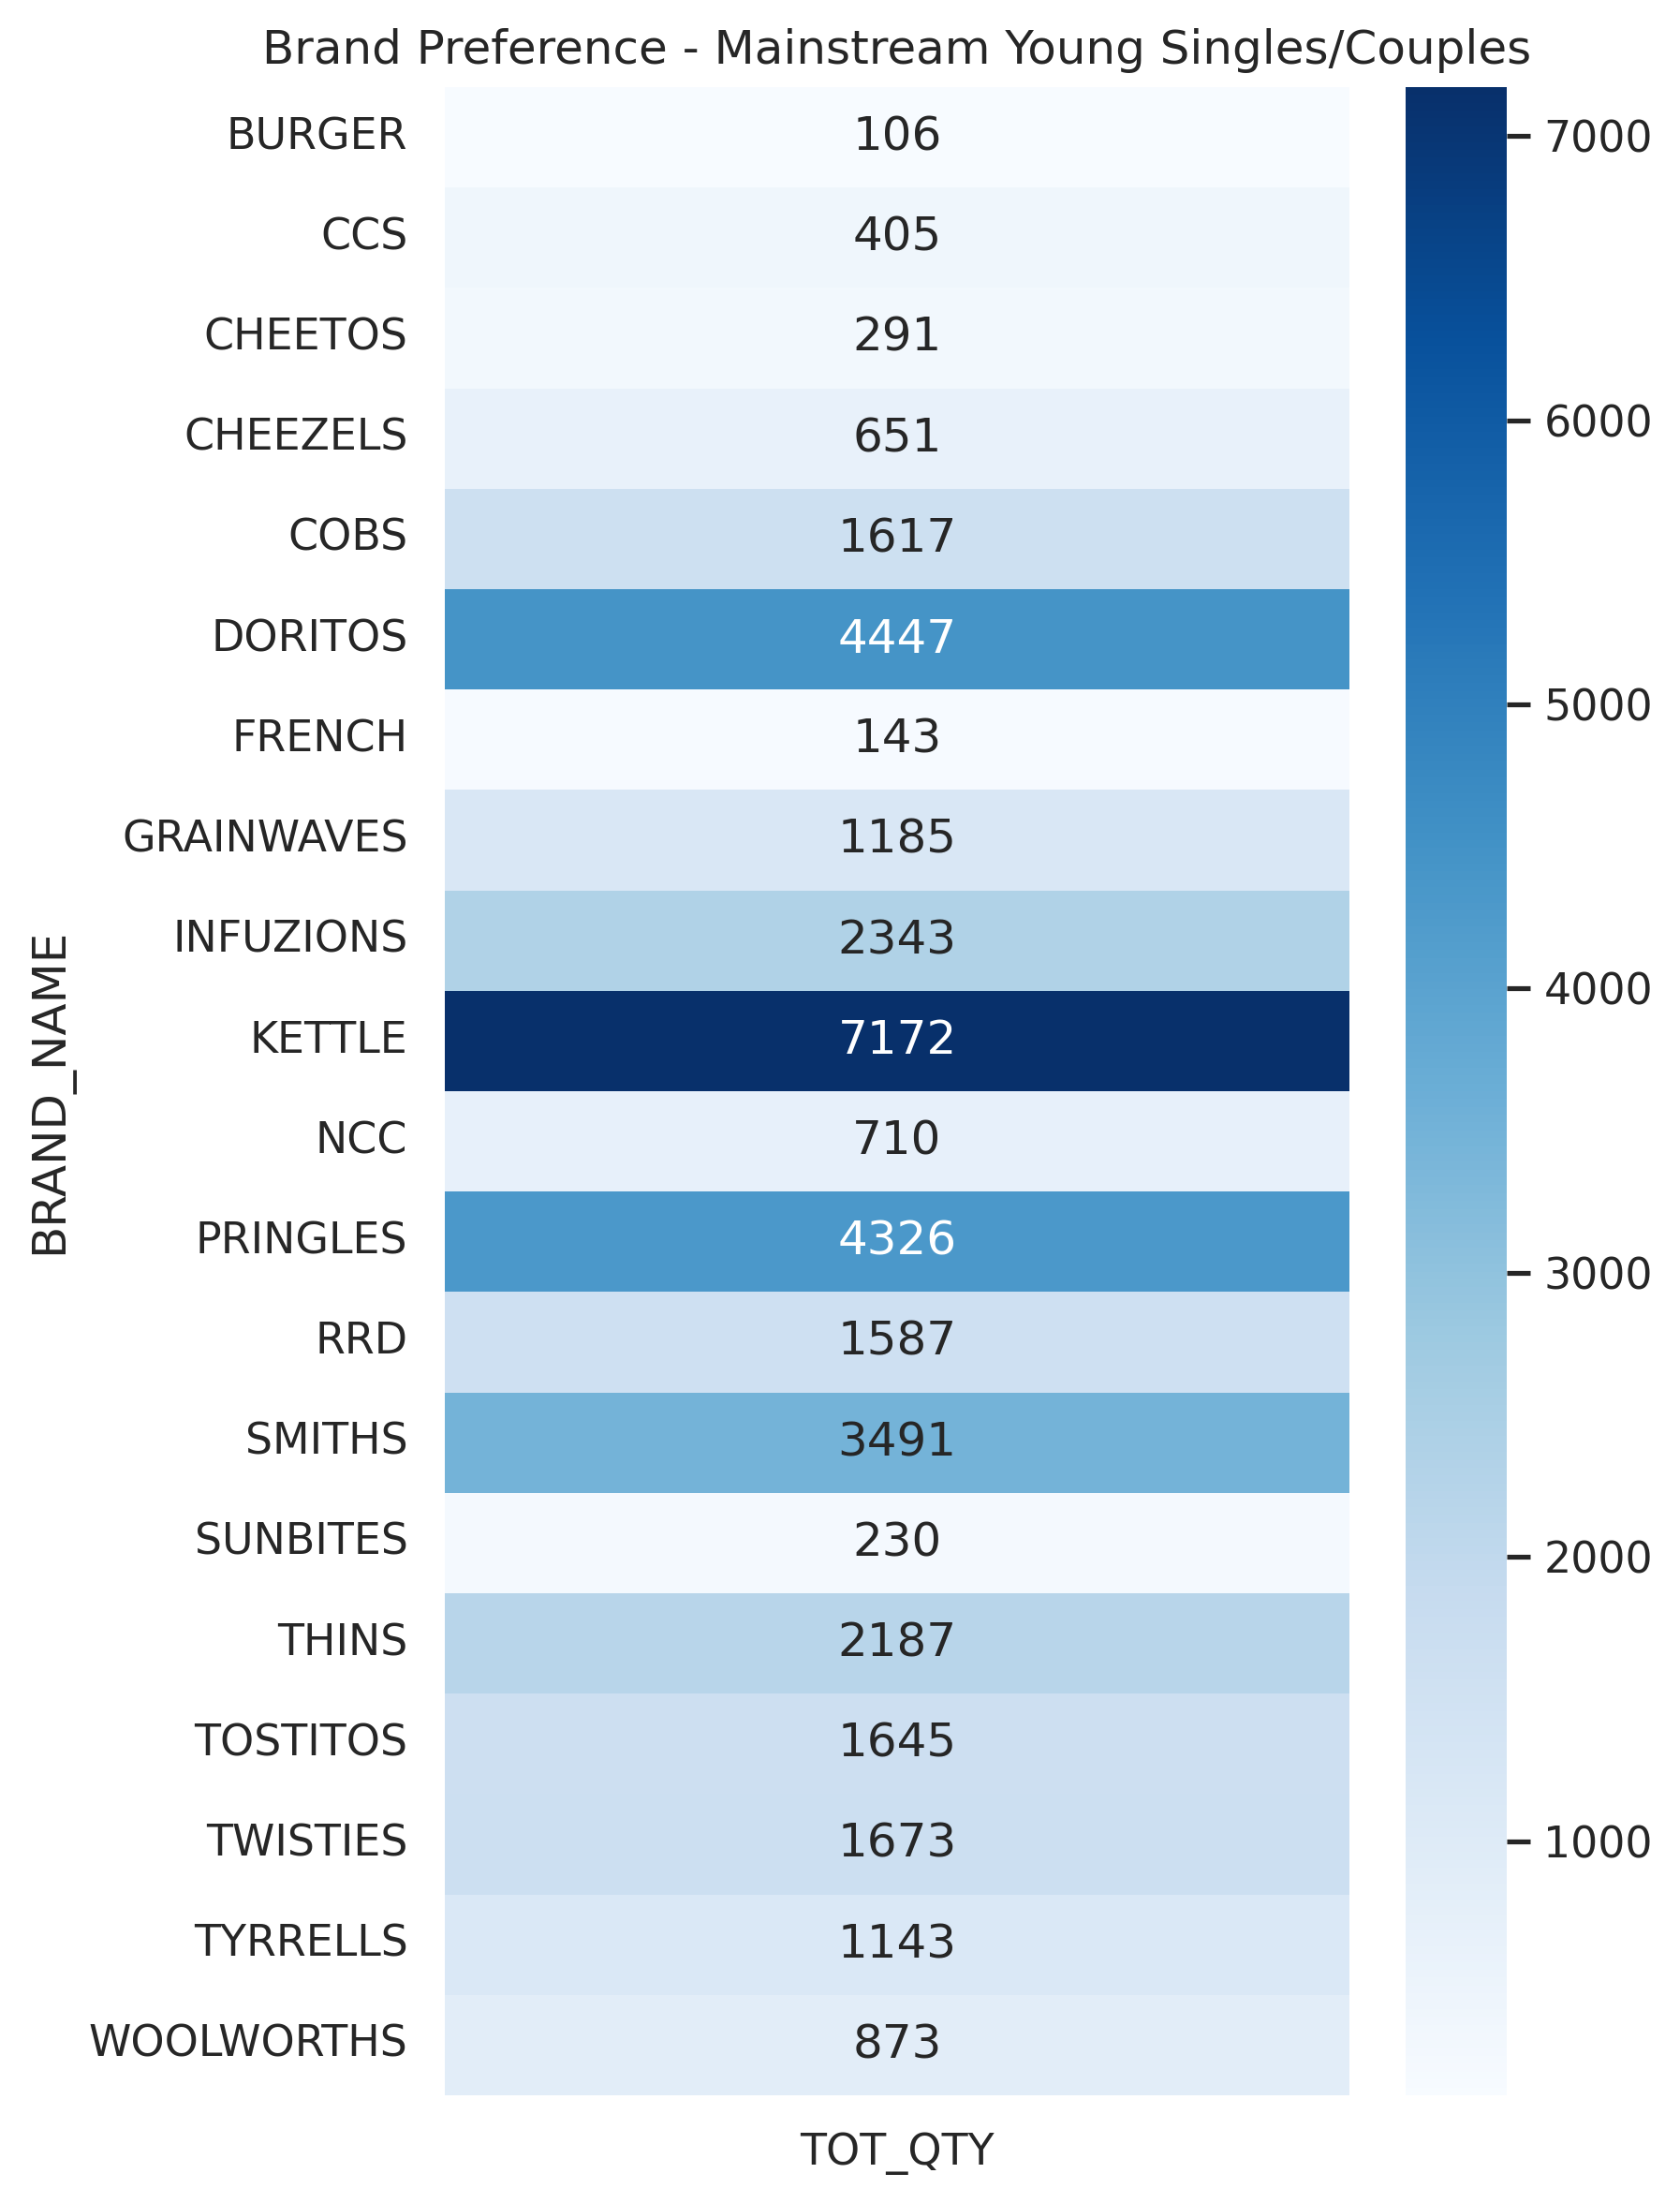

In [79]:
plt.figure(figsize=(6,8), dpi=300)

sns.heatmap(
    brand_share_yg[['TOT_QTY']],   # keep it 2D
    annot=True,
    fmt='d',
    cmap='Blues',
    yticklabels=brand_share_yg['BRAND_NAME']
)

plt.title("Brand Preference - Mainstream Young Singles/Couples")
plt.xlabel("")
plt.ylabel("BRAND_NAME")

plt.tight_layout()
plt.show()

In [80]:
seg_share = segment_yg_main['BRAND_NAME'].value_counts(normalize=True)
overall_share = merged_data['BRAND_NAME'].value_counts(normalize=True)
brand_affinity = (seg_share / overall_share).dropna()
brand_affinity = brand_affinity.sort_values(ascending=False)
print(brand_affinity)

BRAND_NAME
TYRRELLS      1.213098
TWISTIES      1.201858
DORITOS       1.190712
TOSTITOS      1.186370
KETTLE        1.175400
PRINGLES      1.164310
COBS          1.125335
INFUZIONS     1.111264
GRAINWAVES    1.053702
THINS         1.045867
CHEEZELS      0.948989
SMITHS        0.799009
CHEETOS       0.715997
FRENCH        0.694456
RRD           0.676842
NCC           0.665978
CCS           0.615846
SUNBITES      0.537228
WOOLWORTHS    0.510924
BURGER        0.500473
Name: proportion, dtype: float64


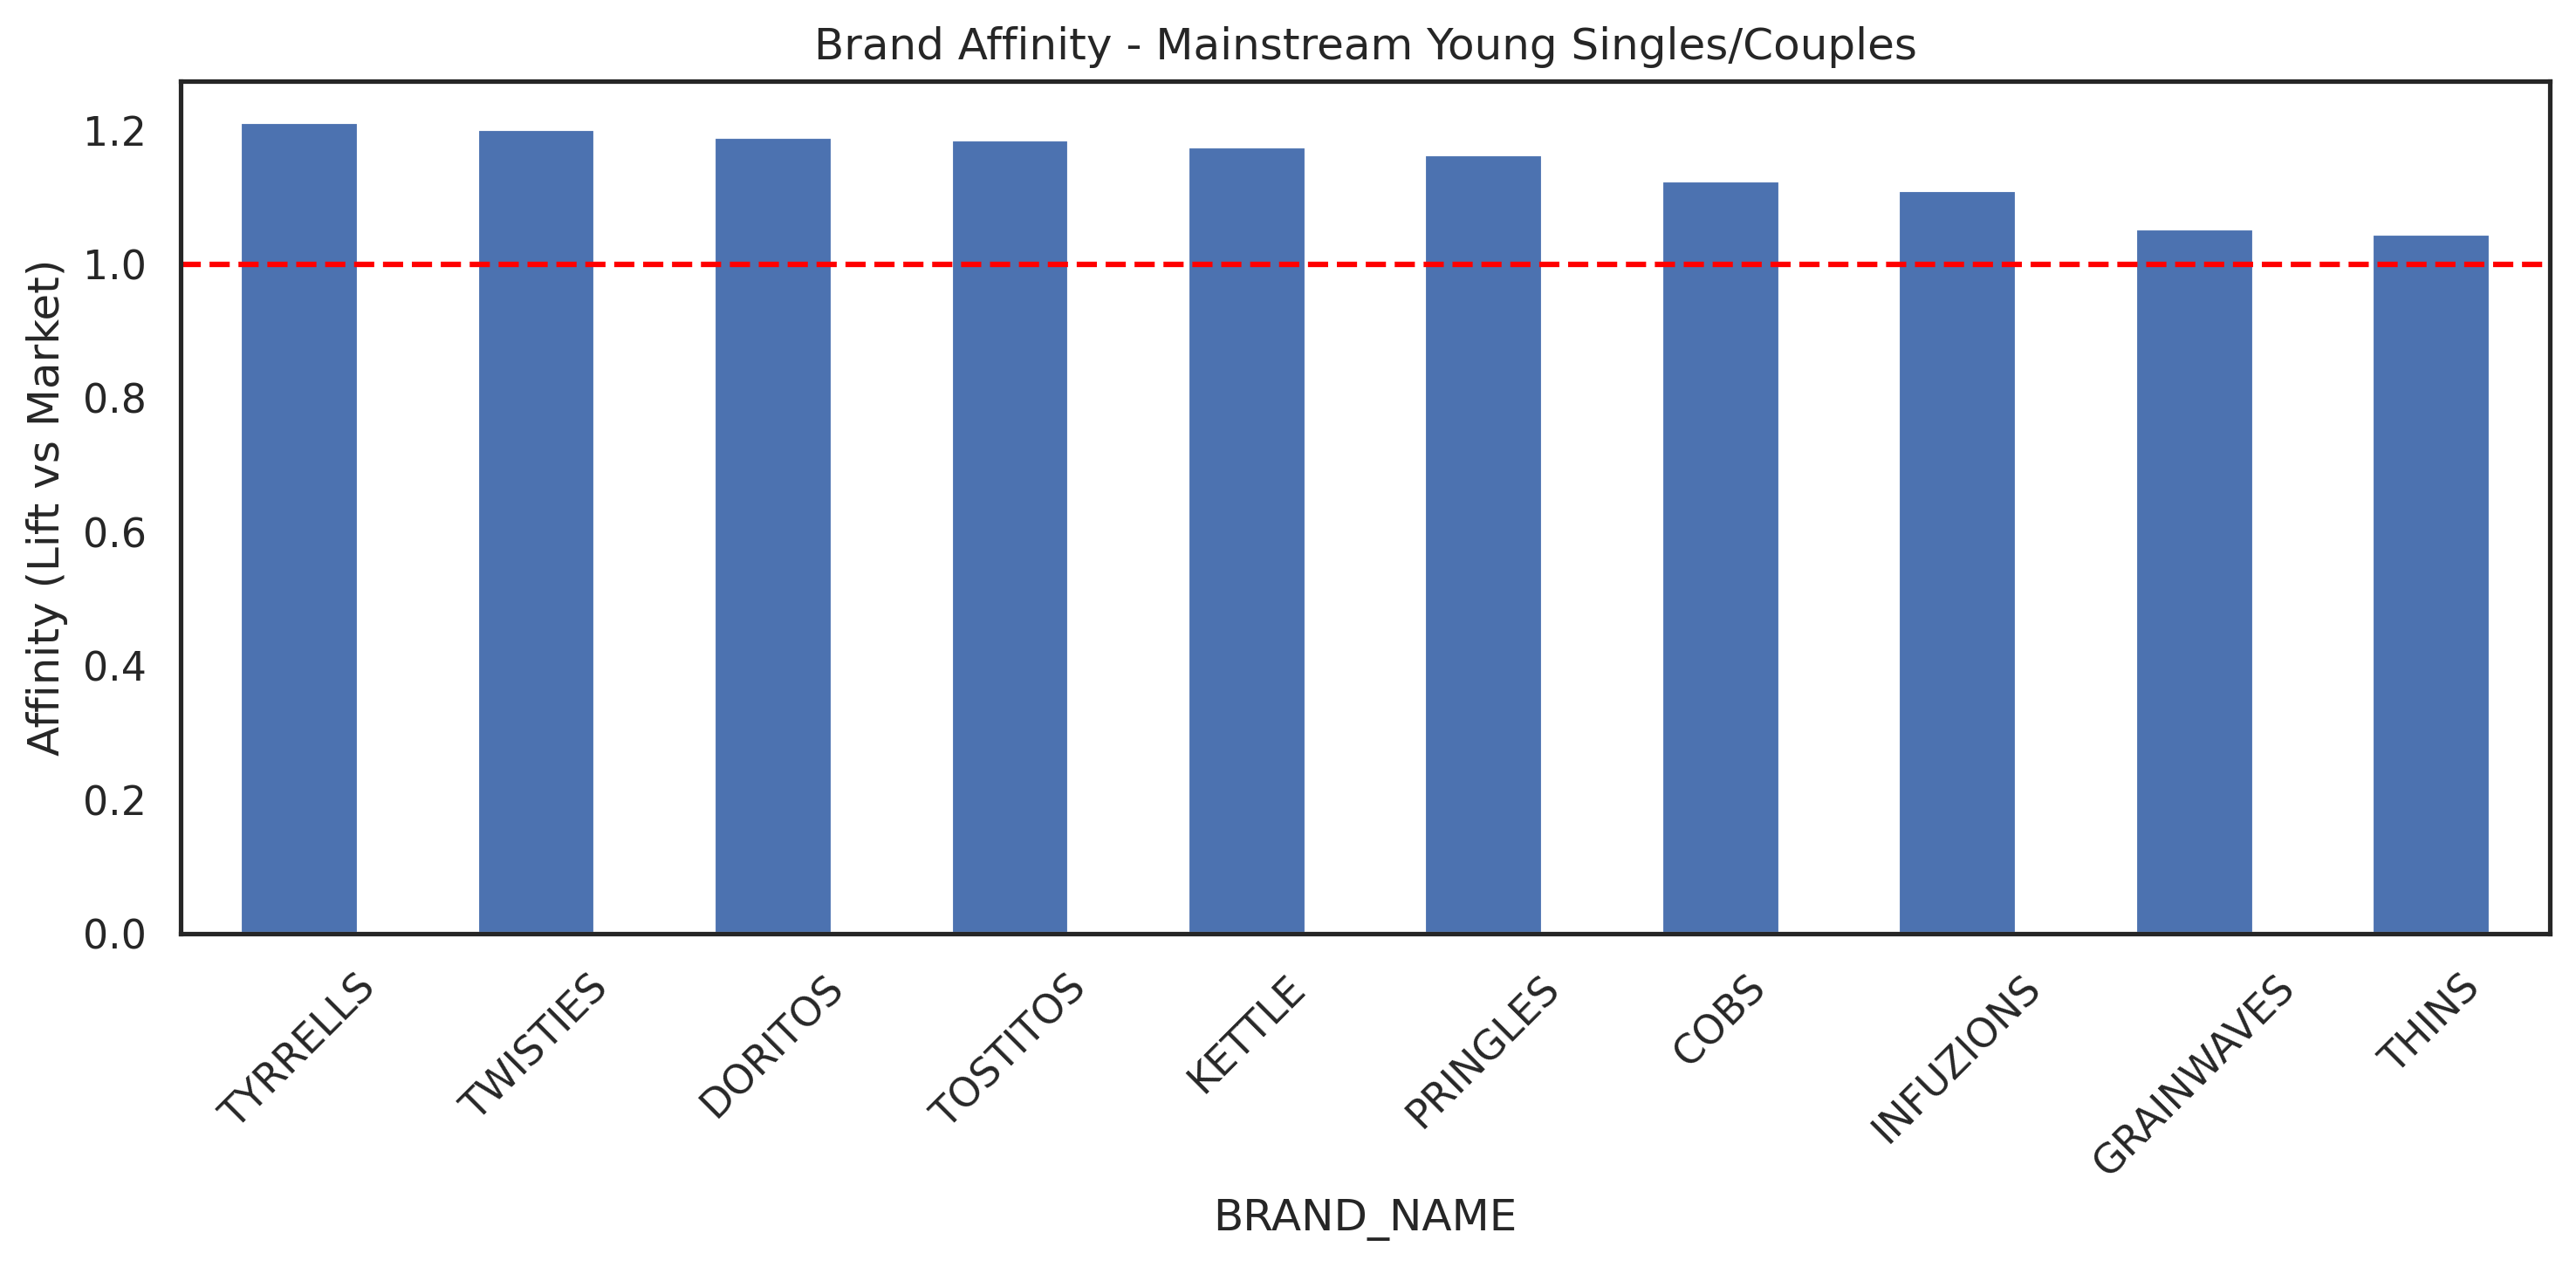

In [81]:
plt.figure(figsize=(10,5), dpi=300)
brand_affinity.head(10).plot(kind='bar')

plt.axhline(1, color='red', linestyle='--')

plt.title("Brand Affinity - Mainstream Young Singles/Couples")
plt.ylabel("Affinity (Lift vs Market)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [82]:
seg_pack = segment_yg_main['PACK_SIZE'].value_counts(normalize=True)
overall_pack = merged_data['PACK_SIZE'].value_counts(normalize=True)
pack_affinity = (seg_pack / overall_pack).dropna()
pack_affinity = pack_affinity.sort_values(ascending=False)
print(pack_affinity)

PACK_SIZE
270    1.245410
380    1.231788
330    1.203085
134    1.164310
210    1.159425
110    1.156634
135    1.124104
250    1.115480
170    0.995052
150    0.967205
175    0.950239
165    0.909497
190    0.623866
180    0.602002
160    0.544101
90     0.537228
70     0.527781
125    0.512287
200    0.505220
220    0.500473
Name: proportion, dtype: float64


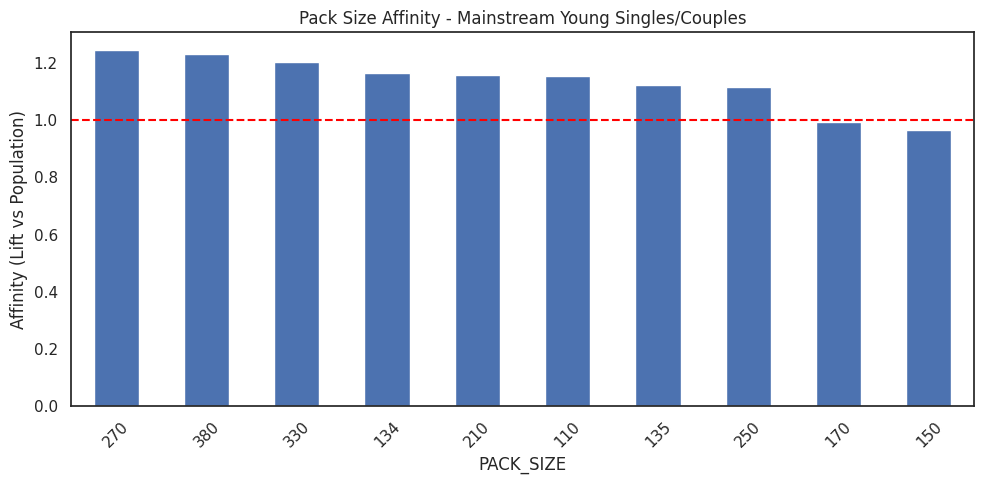

In [83]:
plt.figure(figsize=(10,5))
pack_affinity.head(10).plot(kind='bar')

plt.axhline(1, color='red', linestyle='--')

plt.title("Pack Size Affinity - Mainstream Young Singles/Couples")
plt.ylabel("Affinity (Lift vs Population)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

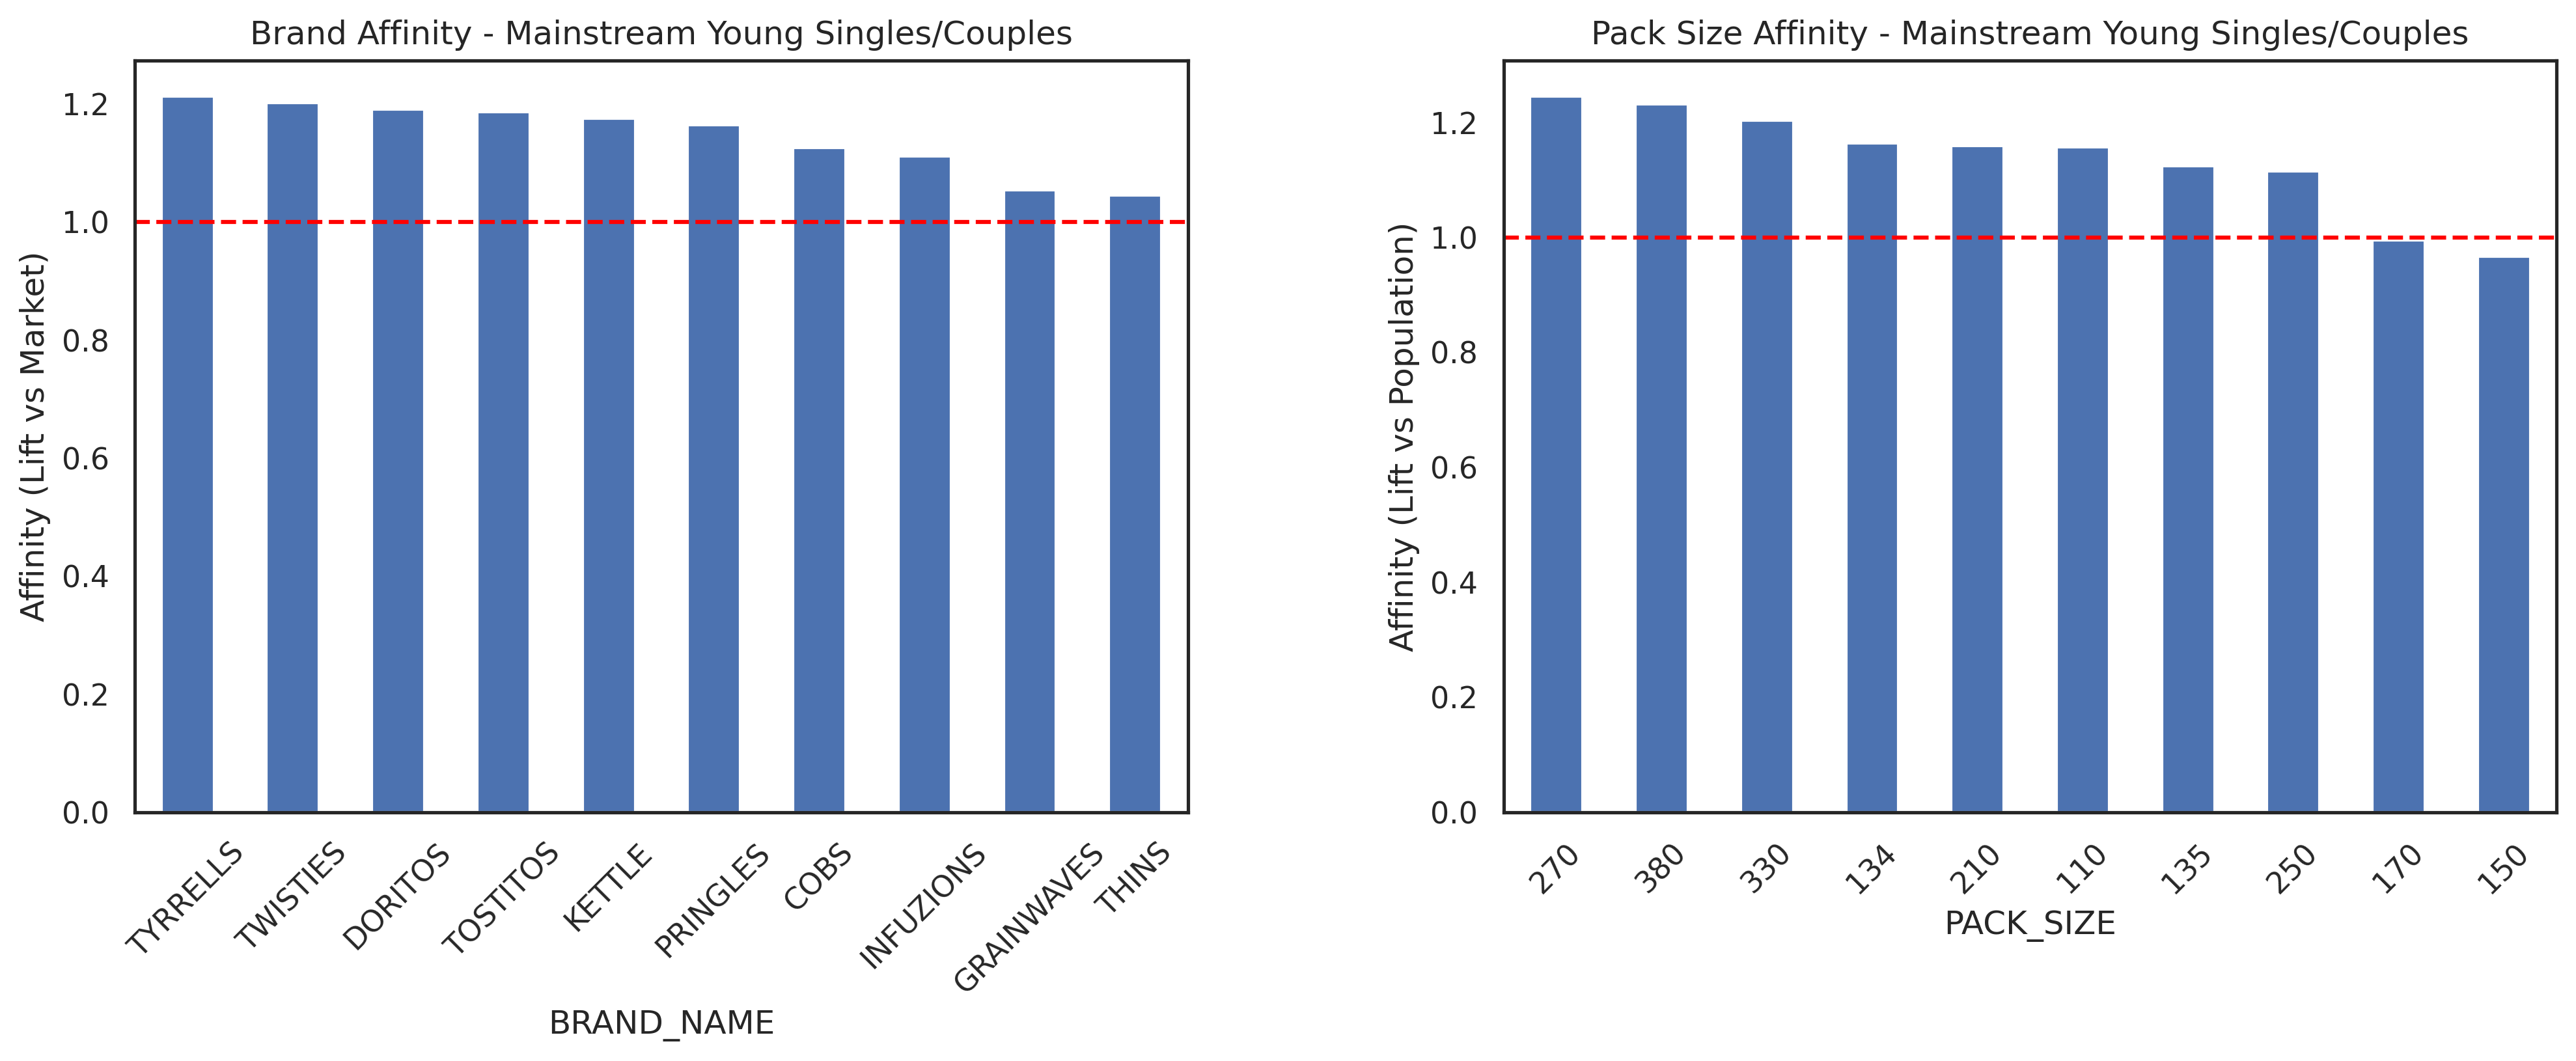

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16,5), dpi=300)

# --- Chart 1: Brand Affinity ---
brand_affinity.head(10).plot(kind='bar', ax=axes[0])
axes[0].axhline(1, color='red', linestyle='--')
axes[0].set_title("Brand Affinity - Mainstream Young Singles/Couples")
axes[0].set_ylabel("Affinity (Lift vs Market)")
axes[0].tick_params(axis='x', rotation=45)

# --- Chart 2: Pack Size Affinity ---
pack_affinity.head(10).plot(kind='bar', ax=axes[1])
axes[1].axhline(1, color='red', linestyle='--')
axes[1].set_title("Pack Size Affinity - Mainstream Young Singles/Couples")
axes[1].set_ylabel("Affinity (Lift vs Population)")
axes[1].tick_params(axis='x', rotation=45)

fig.subplots_adjust(wspace=0.3)
plt.show()


Among mainstream young singles/couples, Kettle is the most frequently purchased brand, indicating the highest total demand within this group.

However, Tyrrells has a higher affinity, meaning it is more strongly overrepresented in this segment compared to other customer groups. In addition, the 270g packet size also shows a higher affinity value.

**RECOMMENDATIONS**

1. **Target High-Value Segments**
* Prioritize mainstream young singles/couples through targeted promotions and personalized offers, as they combine:
  * high visit frequency
  * higher average price per unit
* Leverage older families as a high-value segment by emphasizing value packs and bulk promotions, since they:
  * purchase more units per visit
  * contribute strongly to total sales despite fewer visits

2. **Optimize Product Mix (Brand Strategy)**
* Maintain strong availability and visibility of Kettle, as it drives the highest overall demand.
* Expand targeted promotion of Tyrrells within mainstream young singles/couples, as its high affinity suggests:
    * strong segment-specific preference
    * potential for growth through focused marketing 

3. **Packet Size Strategy**

* Prioritize 130g–180g packet sizes as core inventory, given their highest purchase frequency.
* Promote 270g packet sizes to mainstream young singles/couples, leveraging their higher affinity for this size.
* bundle deals or multi-buy offers may increase basket value

4. **Pricing Strategy**

Since average price per unit is similar across categories but statistically different:
* Introduce subtle price differentiation strategies (e.g., premium positioning for certain brands)
* Test price sensitivity within key segments, especially mainstream young singles/couples

5. **Store Visit vs Basket Behavior**
* Encourage higher basket sizes among frequent visitors (young singles/couples) through:
    * cross-selling (e.g., pairing chips with drinks)
    * bundle promotions
* Increase visit frequency for families through:
    * loyalty programs
    * periodic promotions (e.g., family deals)

6. **Seasonal and Demand Planning**
* Capitalize on strong Christmas demand spikes with:
    * increased inventory
    * seasonal promotions and displays
* Plan flexible promotions outside peak periods, as non-Christmas peaks are more isolated and less predictable.